# MaleVis — FINAL CSE475 Task 3 (Track 3: CNN + Attention)

## Improve, ablate, tune, validate, compare, and explain




In [1]:
# --------------------------- USER CONTROLS ---------------------------

# Complete fresh Task 3 in one Run All.
RUN_CORE_ABLATION = False
RUN_TUNING = False
RUN_FIVE_FOLD_CV = False
RUN_FINAL_TEST = True
RUN_MCNEMAR = False                 # statistics/inference only; never training
RUN_GRADCAM = True
RUN_LIME = True

# Resume only outputs created by this fresh Task 3 notebook.
RESUME_FRESH_TASK3_OUTPUT = True
RESUME_INTERRUPTED_EXPERIMENT = True

# Final test remains locked until the full validation tuning grid is complete.
REQUIRE_COMPLETE_TUNING_FOR_FINAL = True

# Same two Kaggle paths used by MALEV Cnn+Att(5).ipynb.
PROCESSED_DIR_PATH = (
    "/kaggle/input/notebooks/sowhardokabir/notebook0d21ed19ec/"
    "preprocessing_outputs"
)
DATASET_DIR_PATH = (
    "/kaggle/input/datasets/sohamkumar1703/malevis-dataset/"
    "malevis_train_val_300x300"
)

SEED = 42
IMAGE_SIZE = 224
NUM_CLASSES = 25
BATCH_SIZE = 32
INITIAL_LEARNING_RATE = 5e-4
L2_WEIGHT = 1e-5
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 4
LIME_NUM_SAMPLES = 1000
BOOTSTRAP_REPEATS = 1000

FRESH_SCHEMA = "malevis-task3-fresh-v1"

print("Task 2 training sections present: 0")
print("Preprocessed notebook output:", PROCESSED_DIR_PATH)
print("MaleVis dataset:", DATASET_DIR_PATH)
print("Fresh core ablation:", RUN_CORE_ABLATION)
print("Fresh tuning:", RUN_TUNING)
print("Task 3 five-fold CV:", RUN_FIVE_FOLD_CV)
print("Final held-out test:", RUN_FINAL_TEST)
print("Grad-CAM / LIME:", RUN_GRADCAM, "/", RUN_LIME)


Task 2 training sections present: 0
Preprocessed notebook output: /kaggle/input/notebooks/sowhardokabir/notebook0d21ed19ec/preprocessing_outputs
MaleVis dataset: /kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300
Fresh core ablation: False
Fresh tuning: False
Task 3 five-fold CV: False
Final held-out test: True
Grad-CAM / LIME: True / True


In [2]:
!pip install -q lime

## Course Task 3 checklist used by this notebook

| Course requirement | Notebook implementation |
|---|---|
| Improve model | Attention type plus controlled dropout, batch-normalization, depth, and augmentation tuning |
| Ablation | No attention, channel attention, spatial attention, and full CBAM under the same backbone/training policy |
| Fair final comparison | Frozen Task 2 baseline, frozen Task 2 first CBAM model, selected Task 3 model, and protocol-labeled related work |
| Five-fold CV | Stratified **and hash-grouped** folds; duplicate hashes cannot cross folds |
| Significance | Two-sided paired Wilcoxon test on fold macro-F1; McNemar on the shared held-out test when frozen Task 2 predictions are available |
| Complete metrics | Accuracy, balanced accuracy, precision, recall, F1, macro/weighted averages, confusion matrix, ROC-AUC, and PR curves |
| Explainability | Grad-CAM and LIME for one correct and one wrong test prediction |
| Honest XAI boundary | Byte-image highlights are model-influential image regions, not causal malware code or program semantics |


## 1. Imports, deterministic setup, and fresh output folders


In [3]:
import os
os.environ.setdefault("TF_DETERMINISTIC_OPS", "1")

import copy
import gc
import hashlib
import itertools
import json
import random
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from scipy.stats import binomtest, wilcoxon
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    train_test_split,
)
from sklearn.preprocessing import label_binarize

KAGGLE_INPUT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working")
OUTPUT_DIR = WORK_ROOT / "malevis_task3_fresh_outputs"
ABLATION_DIR = OUTPUT_DIR / "ablations"
CV_DIR = OUTPUT_DIR / "five_fold_cv"
XAI_DIR = OUTPUT_DIR / "explainability"
PREPROCESSING_FALLBACK_DIR = WORK_ROOT / "task3_rebuilt_preprocessing"

for folder in [
    OUTPUT_DIR, ABLATION_DIR, CV_DIR, XAI_DIR, PREPROCESSING_FALLBACK_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

def set_experiment_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception as exc:
        warnings.warn(f"Deterministic TensorFlow operations unavailable: {exc}")

set_experiment_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Fresh Task 3 output:", OUTPUT_DIR)


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fresh Task 3 output: /kaggle/working/malevis_task3_fresh_outputs


In [4]:
# Recover only a previous saved output created by this exact fresh notebook.
recovered_roots = []
if RESUME_FRESH_TASK3_OUTPUT:
    for manifest_path in sorted(KAGGLE_INPUT.rglob("fresh_task3_manifest.json")):
        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if manifest.get("schema") == FRESH_SCHEMA:
            recovered_roots.append(manifest_path.parent)

if recovered_roots:
    source_root = recovered_roots[0]
    print("Recovering previous fresh Task 3 output:", source_root)
    shutil.copytree(source_root, OUTPUT_DIR, dirs_exist_ok=True)
else:
    print("No earlier output from this fresh notebook was attached.")

fresh_manifest = {
    "schema": FRESH_SCHEMA,
    "task": "CSE475 Task 3 only",
    "dataset": "MaleVis",
    "task2_locked": True,
    "old_task3_results_imported": False,
    "seed": SEED,
}
(OUTPUT_DIR / "fresh_task3_manifest.json").write_text(
    json.dumps(fresh_manifest, indent=2), encoding="utf-8"
)


Recovering previous fresh Task 3 output: /kaggle/input/notebooks/sowhardokabir/notebookf862b9bcaa/malevis_task3_fresh_outputs


173

## 2. Load the attached `notebook0d21ed19ec` preprocessing output directly



In [5]:
# Screenshot-confirmed current Kaggle input folders.
PROCESSED_DIR = Path(PROCESSED_DIR_PATH)
DATASET_DIR = Path(DATASET_DIR_PATH)

TRAIN_CSV = PROCESSED_DIR / "train_split.csv"
INTERNAL_VAL_CSV = PROCESSED_DIR / "internal_validation_split.csv"
TEST_CSV = PROCESSED_DIR / "test_split.csv"
CLASS_NAMES_FILE = PROCESSED_DIR / "class_names.json"
CONFIG_FILE = PROCESSED_DIR / "preprocessing_config.json"

required_input_files = [
    TRAIN_CSV,
    INTERNAL_VAL_CSV,
    TEST_CSV,
    CLASS_NAMES_FILE,
    CONFIG_FILE,
]

print("Preprocessed data folder:", PROCESSED_DIR)
for file_path in required_input_files:
    print(file_path.name, "->", "Found" if file_path.exists() else "Missing")

if not all(file_path.exists() for file_path in required_input_files):
    raise FileNotFoundError(
        "The attached notebook0d21ed19ec output is missing. "
        "In Kaggle, confirm that notebook0d21ed19ec remains listed under "
        "NOTEBOOKS and contains the preprocessing_outputs folder."
    )

if not (DATASET_DIR / "train").is_dir() or not (DATASET_DIR / "val").is_dir():
    raise FileNotFoundError(
        "Malevis Dataset is not attached at the same path used by Task 2: "
        f"{DATASET_DIR}"
    )

PREPROCESSING_DIR = PROCESSED_DIR
print("All preprocessing files verified.")
print("MaleVis image root verified:", DATASET_DIR)


Preprocessed data folder: /kaggle/input/notebooks/sowhardokabir/notebook0d21ed19ec/preprocessing_outputs
train_split.csv -> Found
internal_validation_split.csv -> Found
test_split.csv -> Found
class_names.json -> Found
preprocessing_config.json -> Found
All preprocessing files verified.
MaleVis image root verified: /kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300


In [6]:
# No preprocessing execution or fallback rebuild is needed.
# The attached notebook output verified above is the only split source.
PREPROCESSING_DIR = PROCESSED_DIR


In [7]:
train_df = pd.read_csv(PREPROCESSING_DIR / "train_split.csv")
internal_val_df = pd.read_csv(
    PREPROCESSING_DIR / "internal_validation_split.csv"
)
test_df = pd.read_csv(PREPROCESSING_DIR / "test_split.csv")


# Exact split sizes produced by the completed preprocessing notebook.
expected_split_rows = {
    "train": 6999,
    "internal_validation": 1751,
    "test": 3477,
}
actual_split_rows = {
    "train": len(train_df),
    "internal_validation": len(internal_val_df),
    "test": len(test_df),
}
print("Expected split rows:", expected_split_rows)
print("Loaded split rows:", actual_split_rows)
assert actual_split_rows == expected_split_rows, (
    "The attached preprocessing output does not match the completed verified split."
)

required_columns = {"relative_path", "class_name", "label_id", "hash"}
for split_name, frame in [
    ("Training", train_df),
    ("Internal validation", internal_val_df),
    ("Held-out test", test_df),
]:
    missing = required_columns - set(frame.columns)
    assert not missing, f"{split_name} missing columns: {missing}"
    frame["label_id"] = frame["label_id"].astype(np.int32)
    frame["hash"] = frame["hash"].astype(str)

class_file = PREPROCESSING_DIR / "class_names.json"
if class_file.is_file():
    class_names = json.loads(class_file.read_text(encoding="utf-8"))
else:
    class_map = (
        pd.concat([train_df, internal_val_df, test_df])
        [["label_id", "class_name"]]
        .drop_duplicates()
        .sort_values("label_id")
    )
    assert class_map["label_id"].tolist() == list(range(NUM_CLASSES))
    class_names = class_map["class_name"].tolist()

assert len(class_names) == NUM_CLASSES
assert all(frame["label_id"].nunique() == NUM_CLASSES for frame in [
    train_df, internal_val_df, test_df
])

train_hashes = set(train_df["hash"])
val_hashes = set(internal_val_df["hash"])
test_hashes = set(test_df["hash"])
assert train_hashes.isdisjoint(val_hashes)
assert train_hashes.isdisjoint(test_hashes)
assert val_hashes.isdisjoint(test_hashes)

def resolve_image_path(relative_path):
    relative = str(relative_path).replace("\\", "/").lstrip("/")
    candidates = [
        DATASET_DIR / relative,
        DATASET_DIR / "train" / relative,
        DATASET_DIR / "val" / relative,
    ]
    return next((str(path) for path in candidates if path.is_file()), None)

for frame in [train_df, internal_val_df, test_df]:
    frame["current_filepath"] = frame["relative_path"].map(resolve_image_path)

for split_name, frame in [
    ("Training", train_df),
    ("Internal validation", internal_val_df),
    ("Held-out test", test_df),
]:
    missing_paths = int(frame["current_filepath"].isna().sum())
    assert missing_paths == 0, f"{split_name} has {missing_paths} unresolved images"

train_paths = train_df["current_filepath"].astype(str).to_numpy()
train_labels = train_df["label_id"].to_numpy(dtype=np.int32)
internal_val_paths = internal_val_df["current_filepath"].astype(str).to_numpy()
internal_val_labels = internal_val_df["label_id"].to_numpy(dtype=np.int32)
test_paths = test_df["current_filepath"].astype(str).to_numpy()
test_labels = test_df["label_id"].to_numpy(dtype=np.int32)

split_summary_df = pd.DataFrame([
    {"split": "Training", "rows": len(train_df), "unique_hashes": train_df["hash"].nunique()},
    {"split": "Internal validation", "rows": len(internal_val_df), "unique_hashes": internal_val_df["hash"].nunique()},
    {"split": "Held-out test", "rows": len(test_df), "unique_hashes": test_df["hash"].nunique()},
])
display(split_summary_df)
print("Hash leakage across all three splits: 0")
print("Classes:", class_names)


Expected split rows: {'train': 6999, 'internal_validation': 1751, 'test': 3477}
Loaded split rows: {'train': 6999, 'internal_validation': 1751, 'test': 3477}


,split,rows,unique_hashes
0,Training,6999,6771
1,Internal validation,1751,1693
2,Held-out test,3477,3468


Hash leakage across all three splits: 0
Classes: ['Adposhel', 'Agent', 'Allaple', 'Amonetize', 'Androm', 'Autorun', 'BrowseFox', 'Dinwod', 'Elex', 'Expiro', 'Fasong', 'HackKMS', 'Hlux', 'Injector', 'InstallCore', 'MultiPlug', 'Neoreklami', 'Neshta', 'Regrun', 'Sality', 'Snarasite', 'Stantinko', 'VBA', 'VBKrypt', 'Vilsel']


,Training,Internal validation,Held-out test
class_name,,,
Adposhel,280,70,144
Agent,280,70,120
Allaple,280,70,128
Amonetize,281,69,97
Androm,280,70,150
Autorun,280,70,146
BrowseFox,280,70,143
Dinwod,280,70,149
Elex,280,70,150


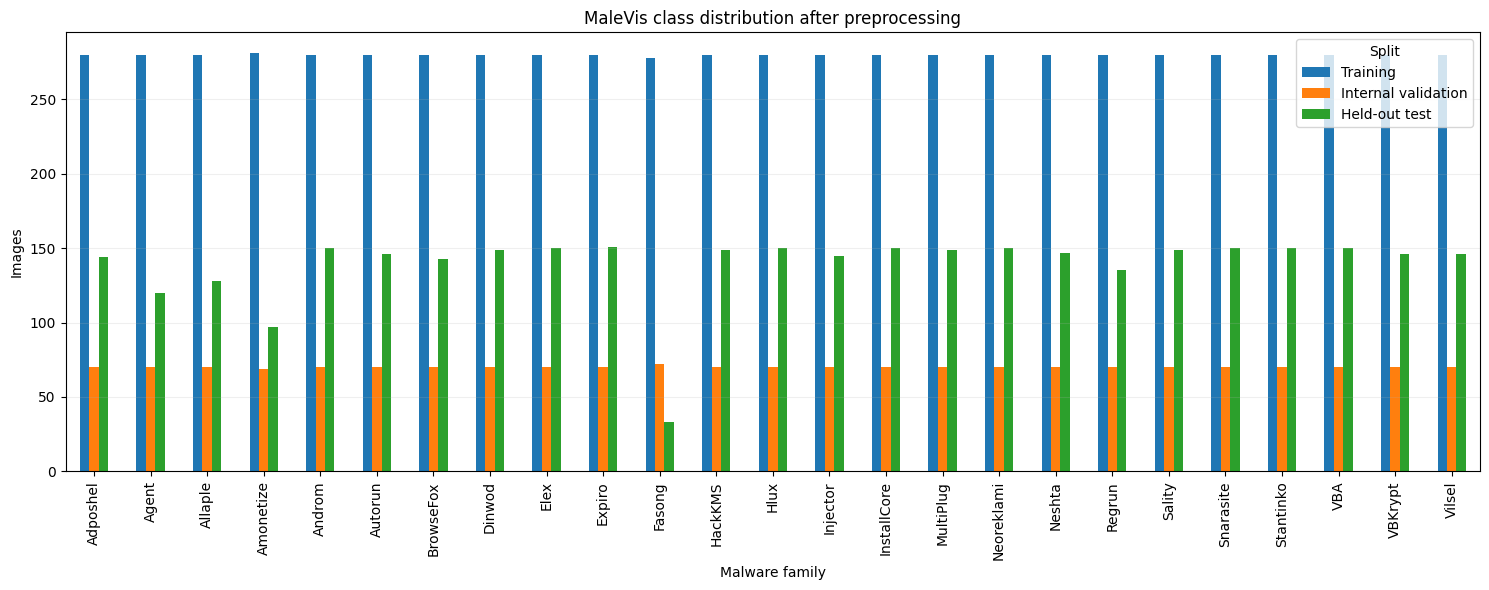

Reading: the development splits remain approximately balanced by class; the held-out support varies after duplicate removal, so macro-F1 and per-class recall remain primary metrics.


In [8]:
distribution_df = pd.DataFrame({
    "Training": train_df["class_name"].value_counts().reindex(class_names),
    "Internal validation": internal_val_df["class_name"].value_counts().reindex(class_names),
    "Held-out test": test_df["class_name"].value_counts().reindex(class_names),
}).fillna(0).astype(int)
display(distribution_df)

distribution_df.plot(kind="bar", figsize=(15, 6))
plt.title("MaleVis class distribution after preprocessing")
plt.xlabel("Malware family")
plt.ylabel("Images")
plt.legend(title="Split")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "preprocessed_class_distribution.png", dpi=200)
plt.show()

print(
    "Reading: the development splits remain approximately balanced by class; "
    "the held-out support varies after duplicate removal, so macro-F1 and "
    "per-class recall remain primary metrics."
)


## 3. Immutable Task 2 reference — no retraining

The values below are transcribed from the executed outputs of the uploaded full
Task 2 notebook. They are never recomputed by fitting Task 2 again. Task 3 results
are stored separately and cannot overwrite them.


In [9]:
TASK2_PROVENANCE = {
    "notebook": "MALEV Cnn+Att(4).ipynb",
    "sha256": "ff520ab7d6b09e68d7e690ea31f24547c460cdc30d6f2b9428ee1c3cb25c5cdb",
    "role": "completed full Task 2",
    "retrained_in_this_notebook": False,
}

task2_reference_df = pd.DataFrame([
    {
        "stage": "Task 2 (frozen)",
        "role": "Best baseline",
        "model": "Generalized CNN",
        "validation_accuracy": 0.7732723951,
        "test_accuracy": 0.7725050331,
        "balanced_accuracy": 0.778714,
        "macro_precision": 0.832588,
        "macro_recall": 0.778714,
        "macro_f1": 0.772953,
        "weighted_precision": 0.828325,
        "weighted_recall": 0.772505,
        "weighted_f1": 0.765556,
        "parameters": 426489,
        "model_size_mb": 4.962336,
        "training_time_sec": 553.985202,
    },
    {
        "stage": "Task 2 (frozen)",
        "role": "First attention model",
        "model": "CNN + CBAM",
        "validation_accuracy": 0.7619,
        "test_accuracy": 0.798102,
        "balanced_accuracy": 0.7740,
        "macro_precision": 0.8176,
        "macro_recall": 0.7740,
        "macro_f1": 0.767742,
        "weighted_precision": 0.8487,
        "weighted_recall": 0.798102,
        "weighted_f1": 0.793594,
        "parameters": 435051,
        "model_size_mb": 5.073773,
        "training_time_sec": 578.043203,
    },
])

task2_reference_df.to_csv(
    OUTPUT_DIR / "frozen_task2_reference_metrics.csv", index=False
)
(OUTPUT_DIR / "frozen_task2_provenance.json").write_text(
    json.dumps(TASK2_PROVENANCE, indent=2), encoding="utf-8"
)
display(task2_reference_df.style.format({
    "validation_accuracy": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
    "model_size_mb": "{:.2f}",
    "training_time_sec": "{:.2f}",
}))
print("Frozen conclusion: CBAM raised Task 2 accuracy and weighted F1, while macro-F1 was slightly lower.")
print("Task 2 models fitted here: 0")


,stage,role,model,validation_accuracy,test_accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,parameters,model_size_mb,training_time_sec
0,Task 2 (frozen),Best baseline,Generalized CNN,0.7733,0.7725,0.778714,0.832588,0.778714,0.7730,0.828325,0.772505,0.7656,426489,4.96,553.99
1,Task 2 (frozen),First attention model,CNN + CBAM,0.7619,0.7981,0.774000,0.817600,0.774000,0.7677,0.848700,0.798102,0.7936,435051,5.07,578.04


Frozen conclusion: CBAM raised Task 2 accuracy and weighted F1, while macro-F1 was slightly lower.
Task 2 models fitted here: 0


## 4. Deterministic image pipeline

Normalization and augmentation match the Task 2 policy. Augmentation is applied
only to a training partition; validation and test images are never augmented.


In [10]:
def make_augmentation(seed):
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomRotation(0.02, seed=seed),
            tf.keras.layers.RandomZoom(0.03, 0.03, seed=seed + 1),
            tf.keras.layers.RandomTranslation(0.02, 0.02, seed=seed + 2),
        ],
        name=f"task3_training_augmentation_{seed}",
    )

def make_dataset(
    image_paths,
    labels,
    *,
    image_size=IMAGE_SIZE,
    training=False,
    augment=False,
    seed=SEED,
    batch_size=BATCH_SIZE,
):
    paths = np.asarray(image_paths).astype(str)
    targets = np.asarray(labels).astype(np.int32)
    dataset = tf.data.Dataset.from_tensor_slices((paths, targets))
    if training:
        dataset = dataset.shuffle(
            len(paths), seed=seed, reshuffle_each_iteration=True
        )

    def decode_resize(path, label):
        image = tf.io.decode_image(
            tf.io.read_file(path), channels=3, expand_animations=False
        )
        image.set_shape([None, None, 3])
        image = tf.image.resize(image, (image_size, image_size))
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    dataset = dataset.map(
        decode_resize,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    ).batch(batch_size)

    if training and augment:
        augmenter = make_augmentation(seed)
        dataset = dataset.map(
            lambda images, batch_labels: (
                augmenter(images, training=True), batch_labels
            ),
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True,
        )
    return dataset.prefetch(tf.data.AUTOTUNE)

pipeline_check = make_dataset(
    train_paths[:BATCH_SIZE], train_labels[:BATCH_SIZE], training=False
)
sample_images, sample_labels = next(iter(pipeline_check))
assert sample_images.shape[1:] == (IMAGE_SIZE, IMAGE_SIZE, 3)
assert float(tf.reduce_min(sample_images)) >= 0.0
assert float(tf.reduce_max(sample_images)) <= 1.0
print("Pipeline check: PASS", sample_images.shape, sample_labels.shape)


I0000 00:00:1787847331.866419      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Pipeline check: PASS (32, 224, 224, 3) (32,)


## 5. Task 3 attention modules and reusable CNN

The backbone reproduces Task 2: four Conv–BN–ReLU–Pool blocks with
32/64/128/256 filters, global average pooling, a 128-unit regularized dense
layer, batch normalization, dropout, and a 25-class softmax. Attention is placed
after the last convolutional activation and before its pooling layer.


In [11]:
@tf.keras.utils.register_keras_serializable(package="MaleVis")
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        self.channels = int(input_shape[-1])
        hidden = max(self.channels // self.reduction_ratio, 1)
        self.dense_1 = tf.keras.layers.Dense(hidden, activation="relu")
        self.dense_2 = tf.keras.layers.Dense(self.channels)
        super().build(input_shape)

    def call(self, inputs):
        average = tf.reduce_mean(inputs, axis=[1, 2])
        maximum = tf.reduce_max(inputs, axis=[1, 2])
        weights = tf.nn.sigmoid(
            self.dense_2(self.dense_1(average))
            + self.dense_2(self.dense_1(maximum))
        )
        return inputs * tf.reshape(weights, (-1, 1, 1, self.channels))

    def get_config(self):
        return {**super().get_config(), "reduction_ratio": self.reduction_ratio}

@tf.keras.utils.register_keras_serializable(package="MaleVis")
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.spatial_conv = tf.keras.layers.Conv2D(
            1,
            self.kernel_size,
            padding="same",
            activation="sigmoid",
            use_bias=False,
        )
        super().build(input_shape)

    def call(self, inputs):
        average = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        maximum = tf.reduce_max(inputs, axis=-1, keepdims=True)
        descriptor = tf.concat([average, maximum], axis=-1)
        return inputs * self.spatial_conv(descriptor)

    def get_config(self):
        return {**super().get_config(), "kernel_size": self.kernel_size}

@tf.keras.utils.register_keras_serializable(package="MaleVis")
class CBAMAttention(tf.keras.layers.Layer):
    def __init__(self, reduction_ratio=16, spatial_kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
        self.spatial_kernel_size = spatial_kernel_size
        self.channel = ChannelAttention(reduction_ratio)
        self.spatial = SpatialAttention(spatial_kernel_size)

    def call(self, inputs):
        return self.spatial(self.channel(inputs))

    def get_config(self):
        return {
            **super().get_config(),
            "reduction_ratio": self.reduction_ratio,
            "spatial_kernel_size": self.spatial_kernel_size,
        }

CUSTOM_OBJECTS = {
    "ChannelAttention": ChannelAttention,
    "SpatialAttention": SpatialAttention,
    "CBAMAttention": CBAMAttention,
    "MaleVis>ChannelAttention": ChannelAttention,
    "MaleVis>SpatialAttention": SpatialAttention,
    "MaleVis>CBAMAttention": CBAMAttention,
}
print("Serializable channel, spatial, and CBAM modules defined.")


Serializable channel, spatial, and CBAM modules defined.


In [12]:
BASE_CONFIG = {
    "attention": "none",
    "dropout": 0.40,
    "batch_norm": True,
    "filters": [32, 64, 128, 256],
    "kernel_size": 3,
    "augmentation": True,
    "learning_rate": INITIAL_LEARNING_RATE,
    "optimizer": "adam",
    "image_size": IMAGE_SIZE,
    "l2_weight": L2_WEIGHT,
    "eligible_final": False,
}

def build_task3_model(config):
    filters = tuple(config.get("filters", BASE_CONFIG["filters"]))
    image_size = int(config.get("image_size", IMAGE_SIZE))
    kernel_size = int(config.get("kernel_size", 3))
    attention = str(config.get("attention", "none"))
    dropout = float(config.get("dropout", 0.40))
    use_batch_norm = bool(config.get("batch_norm", True))
    l2_weight = float(config.get("l2_weight", L2_WEIGHT))

    inputs = tf.keras.layers.Input(
        (image_size, image_size, 3), name="input_image"
    )
    x = inputs
    for block_number, filter_count in enumerate(filters, start=1):
        x = tf.keras.layers.Conv2D(
            filter_count,
            kernel_size,
            padding="same",
            use_bias=not use_batch_norm,
            kernel_regularizer=tf.keras.regularizers.l2(l2_weight),
            name=f"conv_block_{block_number}",
        )(x)
        if use_batch_norm:
            x = tf.keras.layers.BatchNormalization(
                name=f"bn_block_{block_number}"
            )(x)
        x = tf.keras.layers.Activation(
            "relu", name=f"relu_block_{block_number}"
        )(x)

        if block_number == len(filters):
            if attention == "channel":
                x = ChannelAttention(16, name="channel_attention")(x)
            elif attention == "spatial":
                x = SpatialAttention(7, name="spatial_attention")(x)
            elif attention == "cbam":
                x = CBAMAttention(16, 7, name="cbam_attention")(x)
            elif attention != "none":
                raise ValueError(f"Unknown attention type: {attention}")

        x = tf.keras.layers.MaxPooling2D(
            2, name=f"pool_block_{block_number}"
        )(x)

    x = tf.keras.layers.GlobalAveragePooling2D(name="global_pool")(x)
    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_weight),
        name="classifier_dense",
    )(x)
    if use_batch_norm:
        x = tf.keras.layers.BatchNormalization(name="classifier_bn")(x)
    x = tf.keras.layers.Dropout(dropout, name="classifier_dropout")(x)
    outputs = tf.keras.layers.Dense(
        NUM_CLASSES, activation="softmax", name="predictions"
    )(x)
    return tf.keras.Model(inputs, outputs, name="malevis_task3_cnn")

def make_optimizer(config):
    name = str(config.get("optimizer", "adam")).lower()
    learning_rate = float(config.get("learning_rate", INITIAL_LEARNING_RATE))
    if name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "adamw":
        return tf.keras.optimizers.AdamW(
            learning_rate=learning_rate, weight_decay=1e-5
        )
    raise ValueError(f"Unsupported optimizer: {name}")

print("Task 3 model factory created. No model has been fitted.")


Task 3 model factory created. No model has been fitted.


## 6. Metrics, checkpoints, and safe experiment runner

Selection uses internal-validation **macro-F1**. Checkpoints monitor validation
loss, use early stopping, and reduce the learning rate on plateaus. Each finished
experiment immediately saves its configuration, log, validation predictions,
metrics, curves, and best `.keras` checkpoint.


In [13]:
def write_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2), encoding="utf-8")

def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def predict_dataset(model, dataset):
    true_batches, probability_batches = [], []
    start = time.perf_counter()
    for images, labels in dataset:
        true_batches.append(labels.numpy())
        probability_batches.append(model(images, training=False).numpy())
    elapsed = time.perf_counter() - start
    y_true = np.concatenate(true_batches)
    y_probability = np.concatenate(probability_batches)
    y_pred = y_probability.argmax(axis=1)
    return y_true, y_probability, y_pred, elapsed

def metric_row(y_true, y_pred, y_probability=None):
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    row = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall": float(weighted_r),
        "weighted_f1": float(weighted_f1),
        "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
    }
    if y_probability is not None:
        row["log_loss"] = float(
            log_loss(y_true, y_probability, labels=np.arange(NUM_CLASSES))
        )
        try:
            row["macro_roc_auc_ovr"] = float(roc_auc_score(
                y_true,
                y_probability,
                labels=np.arange(NUM_CLASSES),
                multi_class="ovr",
                average="macro",
            ))
        except ValueError:
            row["macro_roc_auc_ovr"] = None
    return row

def make_callbacks(experiment_dir, append_log=False):
    experiment_dir = Path(experiment_dir)
    experiment_dir.mkdir(parents=True, exist_ok=True)
    checkpoint = experiment_dir / "best_model.keras"
    log_path = experiment_dir / "training_log.csv"
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(log_path, append=append_log),
        tf.keras.callbacks.TerminateOnNaN(),
    ]
    return callbacks, checkpoint, log_path

def log_status(log_path):
    log_path = Path(log_path)
    if not log_path.is_file():
        return False, 0, None
    frame = pd.read_csv(log_path)
    if frame.empty or "val_loss" not in frame:
        return False, 0, None
    epochs = len(frame)
    best_epoch = int(frame["val_loss"].astype(float).idxmin()) + 1
    complete = epochs >= MAX_EPOCHS or epochs - best_epoch >= EARLY_STOPPING_PATIENCE
    return bool(complete), int(epochs), int(best_epoch)

def save_training_curves(log_path, destination, title):
    log = pd.read_csv(log_path)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(log["epoch"] + 1, log["accuracy"], label="Training")
    axes[0].plot(log["epoch"] + 1, log["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title} — accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.2)
    axes[1].plot(log["epoch"] + 1, log["loss"], label="Training")
    axes[1].plot(log["epoch"] + 1, log["val_loss"], label="Validation")
    axes[1].set_title(f"{title} — loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(destination, dpi=190)
    plt.close(fig)

print("Metrics and checkpoint helpers ready.")


Metrics and checkpoint helpers ready.


In [14]:
def evaluate_validation_checkpoint(checkpoint, config, validation_dataset):
    model = tf.keras.models.load_model(
        checkpoint, custom_objects=CUSTOM_OBJECTS, compile=False
    )
    y_true, y_probability, y_pred, inference_seconds = predict_dataset(
        model, validation_dataset
    )
    row = metric_row(y_true, y_pred, y_probability)
    row["parameters"] = int(model.count_params())
    row["validation_inference_seconds"] = float(inference_seconds)
    del model
    tf.keras.backend.clear_session()
    gc.collect()
    return row, y_true, y_pred, y_probability

def run_ablation_experiment(experiment_name, config, run_training):
    experiment_dir = ABLATION_DIR / experiment_name
    metrics_path = experiment_dir / "metrics.json"
    checkpoint = experiment_dir / "best_model.keras"
    log_path = experiment_dir / "training_log.csv"
    experiment_dir.mkdir(parents=True, exist_ok=True)
    write_json(experiment_dir / "config.json", config)

    if metrics_path.is_file():
        print(experiment_name, "-> completed fresh result reused")
        return read_json(metrics_path)

    validation_dataset = make_dataset(
        internal_val_paths,
        internal_val_labels,
        image_size=config["image_size"],
        training=False,
        augment=False,
        seed=SEED,
    )

    complete, epochs_logged, best_epoch = log_status(log_path)
    if complete and checkpoint.is_file():
        row, y_true, y_pred, y_probability = evaluate_validation_checkpoint(
            checkpoint, config, validation_dataset
        )
        row.update({
            "experiment": experiment_name,
            "attention": config["attention"],
            "checkpoint": str(checkpoint),
            "epochs_logged": epochs_logged,
            "best_epoch": best_epoch,
            "run_provenance": "completed fresh Task 3 checkpoint reused",
            "eligible_final": bool(config["eligible_final"]),
        })
        write_json(metrics_path, row)
        return row

    if not run_training:
        print(experiment_name, "-> no fresh result; training switch is off")
        return None

    set_experiment_seed(SEED)
    tf.keras.backend.clear_session()
    gc.collect()

    initial_epoch = 0
    append_log = False
    provenance = "fresh Task 3 training"
    if (
        RESUME_INTERRUPTED_EXPERIMENT
        and checkpoint.is_file()
        and log_path.is_file()
        and epochs_logged > 0
    ):
        model = tf.keras.models.load_model(
            checkpoint, custom_objects=CUSTOM_OBJECTS
        )
        initial_epoch = epochs_logged
        append_log = True
        provenance = "resumed fresh Task 3 from its best checkpoint"
    else:
        model = build_task3_model(config)
        model.compile(
            optimizer=make_optimizer(config),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

    if getattr(model, "optimizer", None) is None:
        model.compile(
            optimizer=make_optimizer(config),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

    training_dataset = make_dataset(
        train_paths,
        train_labels,
        image_size=config["image_size"],
        training=True,
        augment=config["augmentation"],
        seed=SEED,
    )
    callbacks, checkpoint, log_path = make_callbacks(
        experiment_dir, append_log=append_log
    )
    print("\n" + "=" * 72)
    print("FRESH TASK 3 ABLATION:", experiment_name)
    print("Starting epoch:", initial_epoch + 1)
    print("=" * 72)
    started = time.perf_counter()
    model.fit(
        training_dataset,
        validation_data=validation_dataset,
        initial_epoch=initial_epoch,
        epochs=MAX_EPOCHS,
        callbacks=callbacks,
        verbose=2,
    )
    training_seconds = time.perf_counter() - started

    complete, epochs_logged, best_epoch = log_status(log_path)
    if not complete:
        raise RuntimeError(
            f"{experiment_name} stopped before completion. Its checkpoint and log "
            "were preserved; rerun with resume enabled."
        )

    row, y_true, y_pred, y_probability = evaluate_validation_checkpoint(
        checkpoint, config, validation_dataset
    )
    row.update({
        "experiment": experiment_name,
        "attention": config["attention"],
        "checkpoint": str(checkpoint),
        "epochs_logged": epochs_logged,
        "best_epoch": best_epoch,
        "training_time_this_session_sec": float(training_seconds),
        "run_provenance": provenance,
        "eligible_final": bool(config["eligible_final"]),
        "model_size_mb": float(checkpoint.stat().st_size / (1024 ** 2)),
    })
    write_json(metrics_path, row)
    pd.DataFrame({
        "true_label_id": y_true,
        "predicted_label_id": y_pred,
        "confidence": y_probability.max(axis=1),
    }).to_csv(experiment_dir / "validation_predictions.csv", index=False)
    save_training_curves(
        log_path,
        experiment_dir / "training_curves.png",
        experiment_name,
    )
    del model
    tf.keras.backend.clear_session()
    gc.collect()
    return row

def run_experiment_grid(configurations, run_training):
    rows = []
    for experiment_name, config in configurations.items():
        row = run_ablation_experiment(
            experiment_name, config, run_training=run_training
        )
        if row is not None:
            rows.append(row)
            pd.DataFrame(rows).to_csv(
                OUTPUT_DIR / "ablation_progress.csv", index=False
            )
    return pd.DataFrame(rows)


## 7. ABLATION STARTS HERE — four controlled CNN+Attention models

These four models use the same split, seed, backbone, dropout (0.40), batch
normalization, augmentation, optimizer, learning-rate schedule, callbacks, and
epoch limit. The only changed factor is the attention module.

The no-attention and CBAM configurations resemble Task 2 architectures, but these
are new **Task 3 control runs** saved under the fresh Task 3 folder. The immutable
Task 2 table above remains untouched.

| Ablation run | Attention mechanism | Purpose |
| --- | --- | --- |
| `core_no_attention` | None | Matched Task 3 control |
| `core_channel_attention` | Channel | Test channel attention alone |
| `core_spatial_attention` | Spatial | Test spatial attention alone |
| `core_cbam_attention` | Channel + spatial (CBAM) | Test combined attention |


In [15]:
CORE_ABLATION_CONFIGS = {
    "core_no_attention": {
        **BASE_CONFIG,
        "attention": "none",
        "eligible_final": False,
    },
    "core_channel_attention": {
        **BASE_CONFIG,
        "attention": "channel",
        "eligible_final": True,
    },
    "core_spatial_attention": {
        **BASE_CONFIG,
        "attention": "spatial",
        "eligible_final": True,
    },
    "core_cbam_attention": {
        **BASE_CONFIG,
        "attention": "cbam",
        "eligible_final": True,
    },
}
write_json(OUTPUT_DIR / "core_ablation_plan.json", CORE_ABLATION_CONFIGS)

architecture_rows = []
for name, config in CORE_ABLATION_CONFIGS.items():
    tf.keras.backend.clear_session()
    temporary_model = build_task3_model(config)
    architecture_rows.append({
        "experiment": name,
        "attention": config["attention"],
        "parameters": temporary_model.count_params(),
        "dropout": config["dropout"],
        "batch_norm": config["batch_norm"],
        "conv_blocks": len(config["filters"]),
        "augmentation": config["augmentation"],
    })
    del temporary_model
architecture_df = pd.DataFrame(architecture_rows)
display(architecture_df)
architecture_df.to_csv(
    OUTPUT_DIR / "core_ablation_architectures.csv", index=False
)


,experiment,attention,parameters,dropout,batch_norm,conv_blocks,augmentation
0,core_no_attention,none,426489,0.4,True,4,True
1,core_channel_attention,channel,434953,0.4,True,4,True
2,core_spatial_attention,spatial,426587,0.4,True,4,True
3,core_cbam_attention,cbam,435051,0.4,True,4,True


core_no_attention -> completed fresh result reused
core_channel_attention -> completed fresh result reused
core_spatial_attention -> completed fresh result reused
core_cbam_attention -> completed fresh result reused


,experiment,attention,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc_ovr,log_loss,parameters,epochs_logged
0,core_cbam_attention,cbam,0.7590,0.7596,0.8142,0.7596,0.7492,0.7488,0.9847,0.8190,435051,15
1,core_no_attention,none,0.5385,0.5381,0.6177,0.5381,0.5200,0.5203,0.9474,1.6371,426489,7
2,core_channel_attention,channel,0.5311,0.5303,0.6691,0.5303,0.5182,0.5190,0.9553,1.5379,434953,12
3,core_spatial_attention,spatial,0.5157,0.5149,0.5092,0.5149,0.4452,0.4458,0.9623,1.6496,426587,7


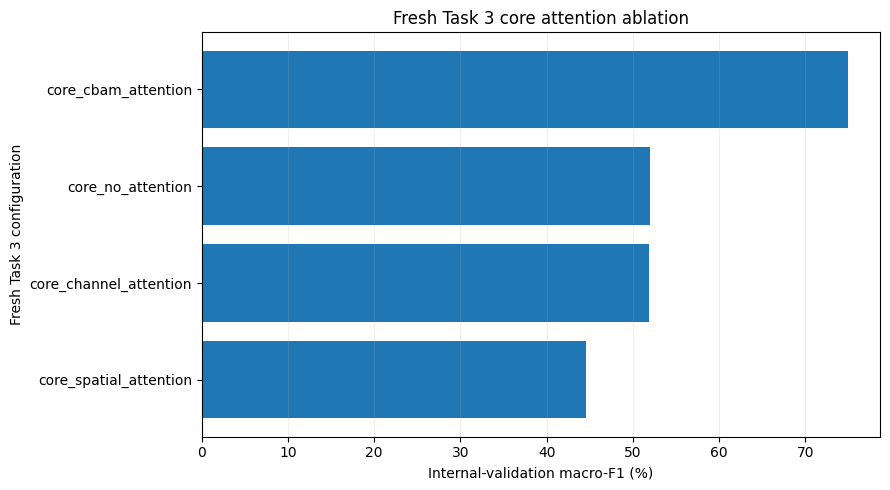

Core ablation complete: True


In [16]:
core_results_df = run_experiment_grid(
    CORE_ABLATION_CONFIGS, run_training=RUN_CORE_ABLATION
)
core_complete = (
    len(core_results_df) == len(CORE_ABLATION_CONFIGS)
    and set(core_results_df["experiment"]) == set(CORE_ABLATION_CONFIGS)
)

if not core_results_df.empty:
    core_results_df = core_results_df.sort_values(
        ["macro_f1", "accuracy"], ascending=False
    ).reset_index(drop=True)
    core_results_df.to_csv(
        OUTPUT_DIR / "core_ablation_results.csv", index=False
    )
    display(core_results_df[[
        "experiment", "attention", "accuracy", "balanced_accuracy",
        "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
        "macro_roc_auc_ovr", "log_loss", "parameters", "epochs_logged",
    ]].style.format({
        "accuracy": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
        "macro_roc_auc_ovr": "{:.4f}",
        "log_loss": "{:.4f}",
    }))

    plot_frame = core_results_df.sort_values("macro_f1")
    plt.figure(figsize=(9, 5))
    plt.barh(plot_frame["experiment"], plot_frame["macro_f1"] * 100)
    plt.xlabel("Internal-validation macro-F1 (%)")
    plt.ylabel("Fresh Task 3 configuration")
    plt.title("Fresh Task 3 core attention ablation")
    plt.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "core_ablation_macro_f1.png", dpi=200)
    plt.show()
    print("Core ablation complete:", core_complete)
else:
    print("No fresh core-ablation result is available yet.")


## 8. Fresh tuning around the best attention type

After all four core runs finish, the best **attention-bearing** model is chosen by
internal-validation macro-F1. Each tuning run changes one controlled factor while the
held-out test remains inaccessible during selection.

| Factor | Configurations compared |
| --- | --- |
| Dropout | Off (`0.00`), and `0.50` |
| Batch normalization | Baseline on versus off |
| Convolution blocks | Baseline 4 versus 5 blocks |
| Augmentation | Baseline on versus off |

The core ablation separately compares no attention, channel attention, spatial
attention, and CBAM.


In [17]:
TUNING_CONFIGS = {}
CORE_WINNER_NAME = None
CORE_WINNER_CONFIG = None

if core_complete:
    attention_rows = core_results_df[core_results_df["attention"] != "none"]
    CORE_WINNER_NAME = str(attention_rows.iloc[0]["experiment"])
    CORE_WINNER_CONFIG = copy.deepcopy(CORE_ABLATION_CONFIGS[CORE_WINNER_NAME])

    TUNING_CONFIGS = {
        "tune_dropout_off": {
            **CORE_WINNER_CONFIG,
            "dropout": 0.0,
        },
        "tune_dropout_050": {
            **CORE_WINNER_CONFIG,
            "dropout": 0.50,
        },
        "tune_batch_norm_off": {
            **CORE_WINNER_CONFIG,
            "batch_norm": False,
        },
        "tune_five_conv_blocks": {
            **CORE_WINNER_CONFIG,
            "filters": [32, 64, 128, 256, 256],
        },
        "tune_augmentation_off": {
            **CORE_WINNER_CONFIG,
            "augmentation": False,
        },
    }
    write_json(OUTPUT_DIR / "tuning_plan.json", {
        "core_winner": CORE_WINNER_NAME,
        "selection_metric": "internal-validation macro-F1",
        "test_used": False,
        "configurations": TUNING_CONFIGS,
    })
    print("Core attention winner:", CORE_WINNER_NAME)
    display(pd.DataFrame.from_dict(TUNING_CONFIGS, orient="index"))
elif RUN_TUNING:
    raise RuntimeError(
        "Complete all four fresh core-ablation runs before tuning."
    )
else:
    print("Tuning plan will be created after the core ablation is complete.")


Core attention winner: core_cbam_attention


,attention,dropout,batch_norm,filters,kernel_size,augmentation,learning_rate,optimizer,image_size,l2_weight,eligible_final
tune_dropout_off,cbam,0.0,True,"[32, 64, 128, 256]",3,True,0.0005,adam,224,0.00001,True
tune_dropout_050,cbam,0.5,True,"[32, 64, 128, 256]",3,True,0.0005,adam,224,0.00001,True
tune_batch_norm_off,cbam,0.4,False,"[32, 64, 128, 256]",3,True,0.0005,adam,224,0.00001,True
tune_five_conv_blocks,cbam,0.4,True,"[32, 64, 128, 256, 256]",3,True,0.0005,adam,224,0.00001,True
tune_augmentation_off,cbam,0.4,True,"[32, 64, 128, 256]",3,False,0.0005,adam,224,0.00001,True


In [18]:
tuning_results_df = run_experiment_grid(
    TUNING_CONFIGS, run_training=RUN_TUNING
) if TUNING_CONFIGS else pd.DataFrame()

tuning_complete = (
    bool(TUNING_CONFIGS)
    and len(tuning_results_df) == len(TUNING_CONFIGS)
    and set(tuning_results_df["experiment"]) == set(TUNING_CONFIGS)
)

if not tuning_results_df.empty:
    tuning_results_df = tuning_results_df.sort_values(
        ["macro_f1", "accuracy"], ascending=False
    ).reset_index(drop=True)
    tuning_results_df.to_csv(
        OUTPUT_DIR / "tuning_results.csv", index=False
    )
    display(tuning_results_df[[
        "experiment", "attention", "accuracy", "balanced_accuracy",
        "macro_f1", "weighted_f1", "macro_roc_auc_ovr", "log_loss",
        "parameters", "epochs_logged",
    ]])
    print("Tuning complete:", tuning_complete)
else:
    print("No fresh tuning result is available yet.")


tune_dropout_off -> completed fresh result reused
tune_dropout_050 -> completed fresh result reused
tune_batch_norm_off -> completed fresh result reused
tune_five_conv_blocks -> completed fresh result reused
tune_augmentation_off -> completed fresh result reused


,experiment,attention,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_roc_auc_ovr,log_loss,parameters,epochs_logged
0,tune_augmentation_off,cbam,0.927470,0.927404,0.928149,0.928203,0.994664,0.333458,435051,15
1,tune_dropout_off,cbam,0.762993,0.762816,0.745197,0.745380,0.985067,0.870725,435051,15
2,tune_dropout_050,cbam,0.737293,0.737085,0.722980,0.723204,0.982252,0.874824,435051,12
3,tune_five_conv_blocks,cbam,0.604797,0.604815,0.562896,0.563169,0.964669,1.557942,1025899,6
4,tune_batch_norm_off,cbam,0.556825,0.557557,0.545467,0.544773,0.949425,1.574374,433099,15


Tuning complete: True


In [19]:
available_frames = [frame for frame in [core_results_df, tuning_results_df] if not frame.empty]
all_ablation_results_df = (
    pd.concat(available_frames, ignore_index=True)
    if available_frames else pd.DataFrame()
)

SELECTED_CONFIG_NAME = None
SELECTED_CONFIG = None
selection_record = None
ALL_CONFIGS = {**CORE_ABLATION_CONFIGS, **TUNING_CONFIGS}

if not all_ablation_results_df.empty:
    eligible = all_ablation_results_df[
        all_ablation_results_df["eligible_final"].astype(bool)
    ].sort_values(["macro_f1", "accuracy"], ascending=False)
    if not eligible.empty:
        SELECTED_CONFIG_NAME = str(eligible.iloc[0]["experiment"])
        SELECTED_CONFIG = copy.deepcopy(ALL_CONFIGS[SELECTED_CONFIG_NAME])
        selection_record = {
            "selected_config_name": SELECTED_CONFIG_NAME,
            "selected_config": SELECTED_CONFIG,
            "selection_metric": "internal-validation macro-F1, then accuracy",
            "core_ablation_complete": bool(core_complete),
            "tuning_complete": bool(tuning_complete),
            "selection_status": "final" if tuning_complete else "provisional",
            "heldout_test_used_for_selection": False,
            "old_task3_results_used": False,
            "task2_results_overwritten": False,
        }
        write_json(OUTPUT_DIR / "model_selection.json", selection_record)
        all_ablation_results_df.sort_values(
            ["macro_f1", "accuracy"], ascending=False
        ).to_csv(OUTPUT_DIR / "all_ablation_tuning_results.csv", index=False)
        print(json.dumps(selection_record, indent=2))
else:
    print("A Task 3 model will be selected after fresh ablation results exist.")


{
  "selected_config_name": "tune_augmentation_off",
  "selected_config": {
    "attention": "cbam",
    "dropout": 0.4,
    "batch_norm": true,
    "filters": [
      32,
      64,
      128,
      256
    ],
    "kernel_size": 3,
    "augmentation": false,
    "learning_rate": 0.0005,
    "optimizer": "adam",
    "image_size": 224,
    "l2_weight": 1e-05,
    "eligible_final": true
  },
  "selection_metric": "internal-validation macro-F1, then accuracy",
  "core_ablation_complete": true,
  "tuning_complete": true,
  "selection_status": "final",
  "heldout_test_used_for_selection": false,
  "old_task3_results_used": false,
  "task2_results_overwritten": false
}


## 9. Leakage-free paired five-fold cross-validation

Training and internal validation form the development pool; the held-out test is
excluded. `StratifiedGroupKFold` stratifies labels while grouping by MD5 hash, so
duplicate images can never appear in both sides of a fold.

Each fold trains the selected attention architecture and a matched no-attention
control. These are Task 3 CV fits required for stability evidence; they do not
alter the frozen Task 2 run. The paired two-sided Wilcoxon test compares fold
macro-F1 at α=0.05.


In [20]:
development_paths = np.concatenate([train_paths, internal_val_paths])
development_labels = np.concatenate([train_labels, internal_val_labels])
development_frame = pd.concat([
    train_df.assign(source_split="training"),
    internal_val_df.assign(source_split="internal_validation"),
], ignore_index=True)
development_groups = development_frame["hash"].astype(str).to_numpy()

assert len(development_paths) == len(development_labels) == len(development_groups)
assert set(development_groups).isdisjoint(test_hashes)
assert int(development_frame.groupby("hash")["label_id"].nunique().max()) == 1

cv_splitter = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=SEED
)
fold_indices = list(cv_splitter.split(
    development_paths, development_labels, groups=development_groups
))

fold_assignment = np.full(len(development_labels), -1, dtype=int)
for fold_number, (fold_train, fold_validation) in enumerate(fold_indices, start=1):
    fold_assignment[fold_validation] = fold_number
    assert set(development_groups[fold_train]).isdisjoint(
        set(development_groups[fold_validation])
    )

fold_manifest = development_frame[[
    "relative_path", "class_name", "label_id", "hash", "source_split"
]].copy()
fold_manifest["cv_fold"] = fold_assignment
fold_manifest.to_csv(OUTPUT_DIR / "five_fold_assignment.csv", index=False)
print("Five hash-grouped stratified folds created; test rows included: 0")


Five hash-grouped stratified folds created; test rows included: 0


In [21]:
def train_cv_model(model_label, config, fold_number, train_indices, val_indices):
    safe_label = model_label.lower().replace(" ", "_").replace("-", "_")
    fold_dir = CV_DIR / f"fold_{fold_number}" / safe_label
    metrics_path = fold_dir / "metrics.json"
    checkpoint = fold_dir / "best_model.keras"
    log_path = fold_dir / "training_log.csv"
    fold_dir.mkdir(parents=True, exist_ok=True)
    write_json(fold_dir / "config.json", config)

    if metrics_path.is_file():
        return read_json(metrics_path)
    if not RUN_FIVE_FOLD_CV:
        return None

    fold_seed = SEED + fold_number
    set_experiment_seed(fold_seed)
    tf.keras.backend.clear_session()
    gc.collect()

    training_dataset = make_dataset(
        development_paths[train_indices],
        development_labels[train_indices],
        image_size=config["image_size"],
        training=True,
        augment=config["augmentation"],
        seed=fold_seed,
    )
    validation_dataset = make_dataset(
        development_paths[val_indices],
        development_labels[val_indices],
        image_size=config["image_size"],
        training=False,
        augment=False,
        seed=fold_seed,
    )

    complete, epochs_logged, _ = log_status(log_path)
    initial_epoch = 0
    append_log = False
    if complete and checkpoint.is_file():
        model = tf.keras.models.load_model(
            checkpoint, custom_objects=CUSTOM_OBJECTS, compile=False
        )
    elif (
        RESUME_INTERRUPTED_EXPERIMENT
        and checkpoint.is_file()
        and log_path.is_file()
        and epochs_logged > 0
    ):
        model = tf.keras.models.load_model(
            checkpoint, custom_objects=CUSTOM_OBJECTS
        )
        initial_epoch = epochs_logged
        append_log = True
    else:
        model = build_task3_model(config)
        model.compile(
            optimizer=make_optimizer(config),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

    if not complete:
        if getattr(model, "optimizer", None) is None:
            model.compile(
                optimizer=make_optimizer(config),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"],
            )
        callbacks, checkpoint, log_path = make_callbacks(
            fold_dir, append_log=append_log
        )
        print("\n" + "=" * 72)
        print(f"TASK 3 CV FOLD {fold_number}/5 — {model_label}")
        print("=" * 72)
        started = time.perf_counter()
        model.fit(
            training_dataset,
            validation_data=validation_dataset,
            initial_epoch=initial_epoch,
            epochs=MAX_EPOCHS,
            callbacks=callbacks,
            verbose=2,
        )
        training_seconds = time.perf_counter() - started
    else:
        training_seconds = 0.0

    best_model = tf.keras.models.load_model(
        checkpoint, custom_objects=CUSTOM_OBJECTS, compile=False
    )
    y_true, y_probability, y_pred, inference_seconds = predict_dataset(
        best_model, validation_dataset
    )
    row = metric_row(y_true, y_pred, y_probability)
    complete, epochs_logged, best_epoch = log_status(log_path)
    row.update({
        "fold": fold_number,
        "model": model_label,
        "checkpoint": str(checkpoint),
        "epochs_logged": epochs_logged,
        "best_epoch": best_epoch,
        "training_time_this_session_sec": float(training_seconds),
        "validation_inference_seconds": float(inference_seconds),
        "train_rows": int(len(train_indices)),
        "validation_rows": int(len(val_indices)),
        "train_unique_hashes": int(len(set(development_groups[train_indices]))),
        "validation_unique_hashes": int(len(set(development_groups[val_indices]))),
        "seed": fold_seed,
        "complete": bool(complete),
    })
    write_json(metrics_path, row)
    pd.DataFrame({
        "development_index": val_indices,
        "true_label_id": y_true,
        "predicted_label_id": y_pred,
        "confidence": y_probability.max(axis=1),
    }).to_csv(fold_dir / "fold_predictions.csv", index=False)
    del model, best_model
    tf.keras.backend.clear_session()
    gc.collect()
    return row


In [22]:
cv_rows = []
if SELECTED_CONFIG is None:
    print("CV is waiting for a fresh validation-selected Task 3 configuration.")
else:
    selected_cv_config = copy.deepcopy(SELECTED_CONFIG)
    baseline_cv_config = copy.deepcopy(SELECTED_CONFIG)
    baseline_cv_config["attention"] = "none"
    baseline_cv_config["eligible_final"] = False

    for fold_number, (fold_train, fold_validation) in enumerate(
        fold_indices, start=1
    ):
        for label, config in [
            ("Matched no-attention baseline", baseline_cv_config),
            ("Selected attention model", selected_cv_config),
        ]:
            row = train_cv_model(
                label, config, fold_number, fold_train, fold_validation
            )
            if row is not None:
                cv_rows.append(row)
                pd.DataFrame(cv_rows).to_csv(
                    OUTPUT_DIR / "five_fold_cv_progress.csv", index=False
                )

cv_results_df = pd.DataFrame(cv_rows)
cv_complete = (
    len(cv_results_df) == 10
    and set(cv_results_df["fold"]) == {1, 2, 3, 4, 5}
    and set(cv_results_df["model"]) == {
        "Matched no-attention baseline", "Selected attention model"
    }
)

if cv_complete:
    cv_results_df = cv_results_df.sort_values(["fold", "model"])
    cv_results_df.to_csv(
        OUTPUT_DIR / "five_fold_cv_results.csv", index=False
    )
    metric_columns = [
        "accuracy", "balanced_accuracy", "macro_precision", "macro_recall",
        "macro_f1", "weighted_f1", "macro_roc_auc_ovr", "log_loss"
    ]
    cv_summary_df = cv_results_df.groupby("model")[metric_columns].agg(
        ["mean", "std"]
    )
    cv_summary_df.to_csv(
        OUTPUT_DIR / "five_fold_cv_mean_std.csv"
    )

    paired = cv_results_df.pivot(
        index="fold", columns="model", values="macro_f1"
    )
    differences = (
        paired["Selected attention model"]
        - paired["Matched no-attention baseline"]
    ).to_numpy()
    if np.allclose(differences, 0):
        statistic, p_value = 0.0, 1.0
    else:
        result = wilcoxon(
            paired["Selected attention model"],
            paired["Matched no-attention baseline"],
            alternative="two-sided",
            method="auto",
        )
        statistic = float(result.statistic)
        p_value = float(result.pvalue)

    observed = abs(float(differences.mean()))
    exact_null = [
        abs(float(np.mean(differences * np.asarray(signs))))
        for signs in itertools.product([-1.0, 1.0], repeat=5)
    ]
    exact_sign_flip_p = float(
        np.mean(np.asarray(exact_null) >= observed - 1e-15)
    )
    significance_record = {
        "test": "Wilcoxon signed-rank, paired two-sided",
        "metric": "macro_f1",
        "folds": 5,
        "statistic": statistic,
        "p_value": p_value,
        "alpha": 0.05,
        "significant": bool(p_value < 0.05),
        "mean_attention_minus_baseline": float(differences.mean()),
        "paired_difference_std": float(differences.std(ddof=1)),
        "attention_fold_wins": int((differences > 0).sum()),
        "ties": int((differences == 0).sum()),
        "exact_sign_flip_two_sided_p": exact_sign_flip_p,
        "warning": "Only five paired folds; statistical power and p-value resolution are limited.",
    }
    write_json(
        OUTPUT_DIR / "paired_wilcoxon_macro_f1.json",
        significance_record,
    )
    display(cv_results_df)
    display(cv_summary_df)
    display(paired)
    print(json.dumps(significance_record, indent=2))
else:
    print(f"Five-fold CV progress: {len(cv_results_df)}/10 paired model-fold runs")


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,cohen_kappa,mcc,...,epochs_logged,best_epoch,training_time_this_session_sec,validation_inference_seconds,train_rows,validation_rows,train_unique_hashes,validation_unique_hashes,seed,complete
0,0.926829,0.923897,0.925257,0.923897,0.921905,0.927749,0.926829,0.924771,0.923690,0.923910,...,13,9,423.940582,3.942428,7028,1722,6772,1692,43,True
1,0.958769,0.957896,0.957359,0.957896,0.957385,0.959508,0.958769,0.958901,0.957004,0.957025,...,15,15,500.938790,2.302272,7028,1722,6772,1692,43,True
2,0.904437,0.905477,0.920345,0.905477,0.906198,0.920960,0.904437,0.905687,0.900421,0.901300,...,15,14,446.601807,2.343975,6992,1758,6771,1693,44,True
3,0.970990,0.969791,0.972444,0.969791,0.970522,0.972399,0.970990,0.971111,0.969768,0.969823,...,15,15,469.409244,2.420681,6992,1758,6771,1693,44,True
4,0.944891,0.947061,0.949867,0.947061,0.946958,0.946678,0.944891,0.944135,0.942550,0.942735,...,15,13,447.528088,2.386508,7008,1742,6771,1693,45,True
5,0.965557,0.967002,0.967520,0.967002,0.966779,0.966226,0.965557,0.965392,0.964097,0.964143,...,15,13,471.213314,2.554465,7008,1742,6771,1693,45,True
6,0.920653,0.918574,0.935222,0.918574,0.922102,0.933933,0.920653,0.922355,0.917227,0.917764,...,15,15,447.307295,2.330069,6973,1777,6771,1693,46,True
7,0.960045,0.958223,0.960569,0.958223,0.958083,0.961905,0.960045,0.959695,0.958330,0.958440,...,15,15,470.619322,2.403557,6973,1777,6771,1693,46,True
8,0.954883,0.956363,0.956580,0.956363,0.955572,0.956789,0.954883,0.954928,0.952990,0.953072,...,15,15,447.642973,2.365649,6999,1751,6771,1693,47,True
9,0.961165,0.962531,0.963020,0.962531,0.961273,0.963429,0.961165,0.960766,0.959535,0.959669,...,15,12,468.572179,2.324550,6999,1751,6771,1693,47,True


accuracy           balanced_accuracy            \
                                   mean       std              mean       std   
model                                                                           
Matched no-attention baseline  0.930339  0.019945          0.930274  0.020946   
Selected attention model       0.963305  0.004998          0.963089  0.005272   

                              macro_precision           macro_recall  \
                                         mean       std         mean   
model                                                                  
Matched no-attention baseline        0.937454  0.015543     0.930274   
Selected attention model             0.964182  0.005924     0.963089   

                                         macro_f1           weighted_f1  \
                                    std      mean       std        mean   
model                                                                     
Matched no-attention baseline  0.020946  0.930547  0.020214    0.930375   
Selected attention model       0.005272  0.962808  0.005687    0.963173   

                                        macro_roc_auc_ovr            log_loss  \
                                    std              mean       std      mean   
model                                                                           
Matched no-attention baseline  0.019348          0.996616  0.001039  0.269266   
Selected attention model       0.005101          0.998467  0.000466  0.159524   

                                         
                                    std  
model                                    
Matched no-attention baseline  0.079374  
Selected attention model       0.015936

model,Matched no-attention baseline,Selected attention model
fold,,
1,0.921905,0.957385
2,0.906198,0.970522
3,0.946958,0.966779
4,0.922102,0.958083
5,0.955572,0.961273


{
  "test": "Wilcoxon signed-rank, paired two-sided",
  "metric": "macro_f1",
  "folds": 5,
  "statistic": 0.0,
  "p_value": 0.0625,
  "alpha": 0.05,
  "significant": false,
  "mean_attention_minus_baseline": 0.032261250948759576,
  "paired_difference_std": 0.02186547490256198,
  "attention_fold_wins": 5,
  "ties": 0,
  "exact_sign_flip_two_sided_p": 0.0625,
  "warning": "Only five paired folds; statistical power and p-value resolution are limited."
}


## 10. Lock the validation-selected model and evaluate the test once

The final checkpoint is chosen by internal-validation macro-F1 only. With the
default protection, all tuning rows must exist before test evaluation. The test
is then used once for final reporting—not for another round of tuning.


In [23]:
def selected_checkpoint_path(experiment_name):
    candidate = ABLATION_DIR / experiment_name / "best_model.keras"
    if candidate.is_file():
        return candidate
    raise FileNotFoundError(
        f"No fresh checkpoint for {experiment_name}. Attach/recover the fresh "
        "ablation output or run that experiment first."
    )

LOCKED_MODEL_PATH = OUTPUT_DIR / "malevis_task3_final_model.keras"
final_model = None
final_y_true = None
final_y_pred = None
final_y_probability = None
final_test_metrics = None

if RUN_FINAL_TEST:
    assert SELECTED_CONFIG_NAME is not None
    if REQUIRE_COMPLETE_TUNING_FOR_FINAL:
        assert tuning_complete, (
            "Final test blocked: complete the fresh tuning grid first."
        )
    checkpoint = selected_checkpoint_path(SELECTED_CONFIG_NAME)
    final_model = tf.keras.models.load_model(
        checkpoint, custom_objects=CUSTOM_OBJECTS, compile=False
    )
    final_model.save(LOCKED_MODEL_PATH)
    write_json(OUTPUT_DIR / "locked_model.json", {
        "selected_config_name": SELECTED_CONFIG_NAME,
        "selected_config": SELECTED_CONFIG,
        "source_checkpoint": str(checkpoint),
        "locked_model": str(LOCKED_MODEL_PATH),
        "selection_metric": "internal-validation macro-F1",
        "heldout_test_used_for_selection": False,
        "task2_overwritten": False,
    })

    existing_metrics = OUTPUT_DIR / "final_test_metrics.json"
    existing_predictions = OUTPUT_DIR / "final_test_predictions.csv"
    if existing_metrics.is_file() and existing_predictions.is_file():
        final_test_metrics = read_json(existing_metrics)
        saved_predictions = pd.read_csv(existing_predictions)
        final_y_true = saved_predictions["true_label_id"].to_numpy(dtype=int)
        final_y_pred = saved_predictions["predicted_label_id"].to_numpy(dtype=int)
        probability_path = OUTPUT_DIR / "final_test_probabilities.npy"
        final_y_probability = np.load(probability_path)
        print("Existing final-test result reused; the test was not evaluated again.")
    else:
        test_dataset = make_dataset(
            test_paths,
            test_labels,
            image_size=SELECTED_CONFIG["image_size"],
            training=False,
            augment=False,
            seed=SEED,
        )
        final_y_true, final_y_probability, final_y_pred, inference_seconds = (
            predict_dataset(final_model, test_dataset)
        )
        assert np.array_equal(final_y_true, test_labels)
        final_test_metrics = metric_row(
            final_y_true, final_y_pred, final_y_probability
        )

        def bootstrap_interval(metric_function, seed):
            rng = np.random.default_rng(seed)
            indices = np.arange(len(final_y_true))
            values = []
            for _ in range(BOOTSTRAP_REPEATS):
                sample = rng.choice(indices, size=len(indices), replace=True)
                values.append(metric_function(
                    final_y_true[sample], final_y_pred[sample]
                ))
            return [float(value) for value in np.quantile(values, [0.025, 0.975])]

        final_test_metrics.update({
            "model": SELECTED_CONFIG_NAME,
            "test_rows": int(len(final_y_true)),
            "parameters": int(final_model.count_params()),
            "model_size_mb": float(LOCKED_MODEL_PATH.stat().st_size / (1024 ** 2)),
            "total_inference_seconds": float(inference_seconds),
            "milliseconds_per_image": float(1000 * inference_seconds / len(final_y_true)),
            "accuracy_bootstrap_95_ci": bootstrap_interval(accuracy_score, SEED),
            "macro_f1_bootstrap_95_ci": bootstrap_interval(
                lambda y, p: f1_score(y, p, average="macro", zero_division=0),
                SEED + 1,
            ),
            "heldout_test_used_for_selection": False,
        })
        write_json(existing_metrics, final_test_metrics)
        np.save(
            OUTPUT_DIR / "final_test_probabilities.npy",
            final_y_probability,
        )
        prediction_frame = test_df[[
            "relative_path", "class_name", "label_id", "hash"
        ]].copy()
        prediction_frame["true_label_id"] = final_y_true
        prediction_frame["predicted_label_id"] = final_y_pred
        prediction_frame["predicted_class"] = [
            class_names[index] for index in final_y_pred
        ]
        prediction_frame["confidence"] = final_y_probability.max(axis=1)
        prediction_frame["correct"] = final_y_pred == final_y_true
        prediction_frame.to_csv(existing_predictions, index=False)

        report = classification_report(
            final_y_true,
            final_y_pred,
            labels=np.arange(NUM_CLASSES),
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
        pd.DataFrame(report).T.to_csv(
            OUTPUT_DIR / "final_test_classification_report.csv"
        )
    print(json.dumps(final_test_metrics, indent=2))
else:
    print("Final test is locked. Set RUN_FINAL_TEST=True only after tuning.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cbam_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Existing final-test result reused; the test was not evaluated again.
{
  "accuracy": 0.9269485188380788,
  "balanced_accuracy": 0.9287073878815886,
  "macro_precision": 0.9424894917847524,
  "macro_recall": 0.9287073878815886,
  "macro_f1": 0.9299674123962354,
  "weighted_precision": 0.9403371469174229,
  "weighted_recall": 0.9269485188380788,
  "weighted_f1": 0.9276097969444499,
  "cohen_kappa": 0.9238007889478279,
  "mcc": 0.9244410441874626,
  "log_loss": 0.32792187504118087,
  "macro_roc_auc_ovr": 0.9954076992567024,
  "model": "tune_augmentation_off",
  "test_rows": 3477,
  "parameters": 435051,
  "model_size_mb": 1.7483739852905273,
  "total_inference_seconds": 10.816385348996846,
  "milliseconds_per_image": 3.1108384667808013,
  "accuracy_bootstrap_95_ci": [
    0.9183132010353753,
    0.9355766465343687
  ],
  "macro_f1_bootstrap_95_ci": [
    0.9224288920751296,
    0.937112630472819
  ],
  "heldout_test_used_for_selection": false
}


,precision,recall,f1-score,support
Adposhel,0.979592,1.000000,0.989691,144.000000
Agent,0.881818,0.808333,0.843478,120.000000
Allaple,0.946154,0.960938,0.953488,128.000000
Amonetize,0.978022,0.917526,0.946809,97.000000
Androm,0.871345,0.993333,0.928349,150.000000
Autorun,0.952000,0.815068,0.878229,146.000000
BrowseFox,1.000000,0.937063,0.967509,143.000000
Dinwod,0.844828,0.986577,0.910217,149.000000
Elex,0.993007,0.946667,0.969283,150.000000
Expiro,1.000000,0.529801,0.692641,151.000000


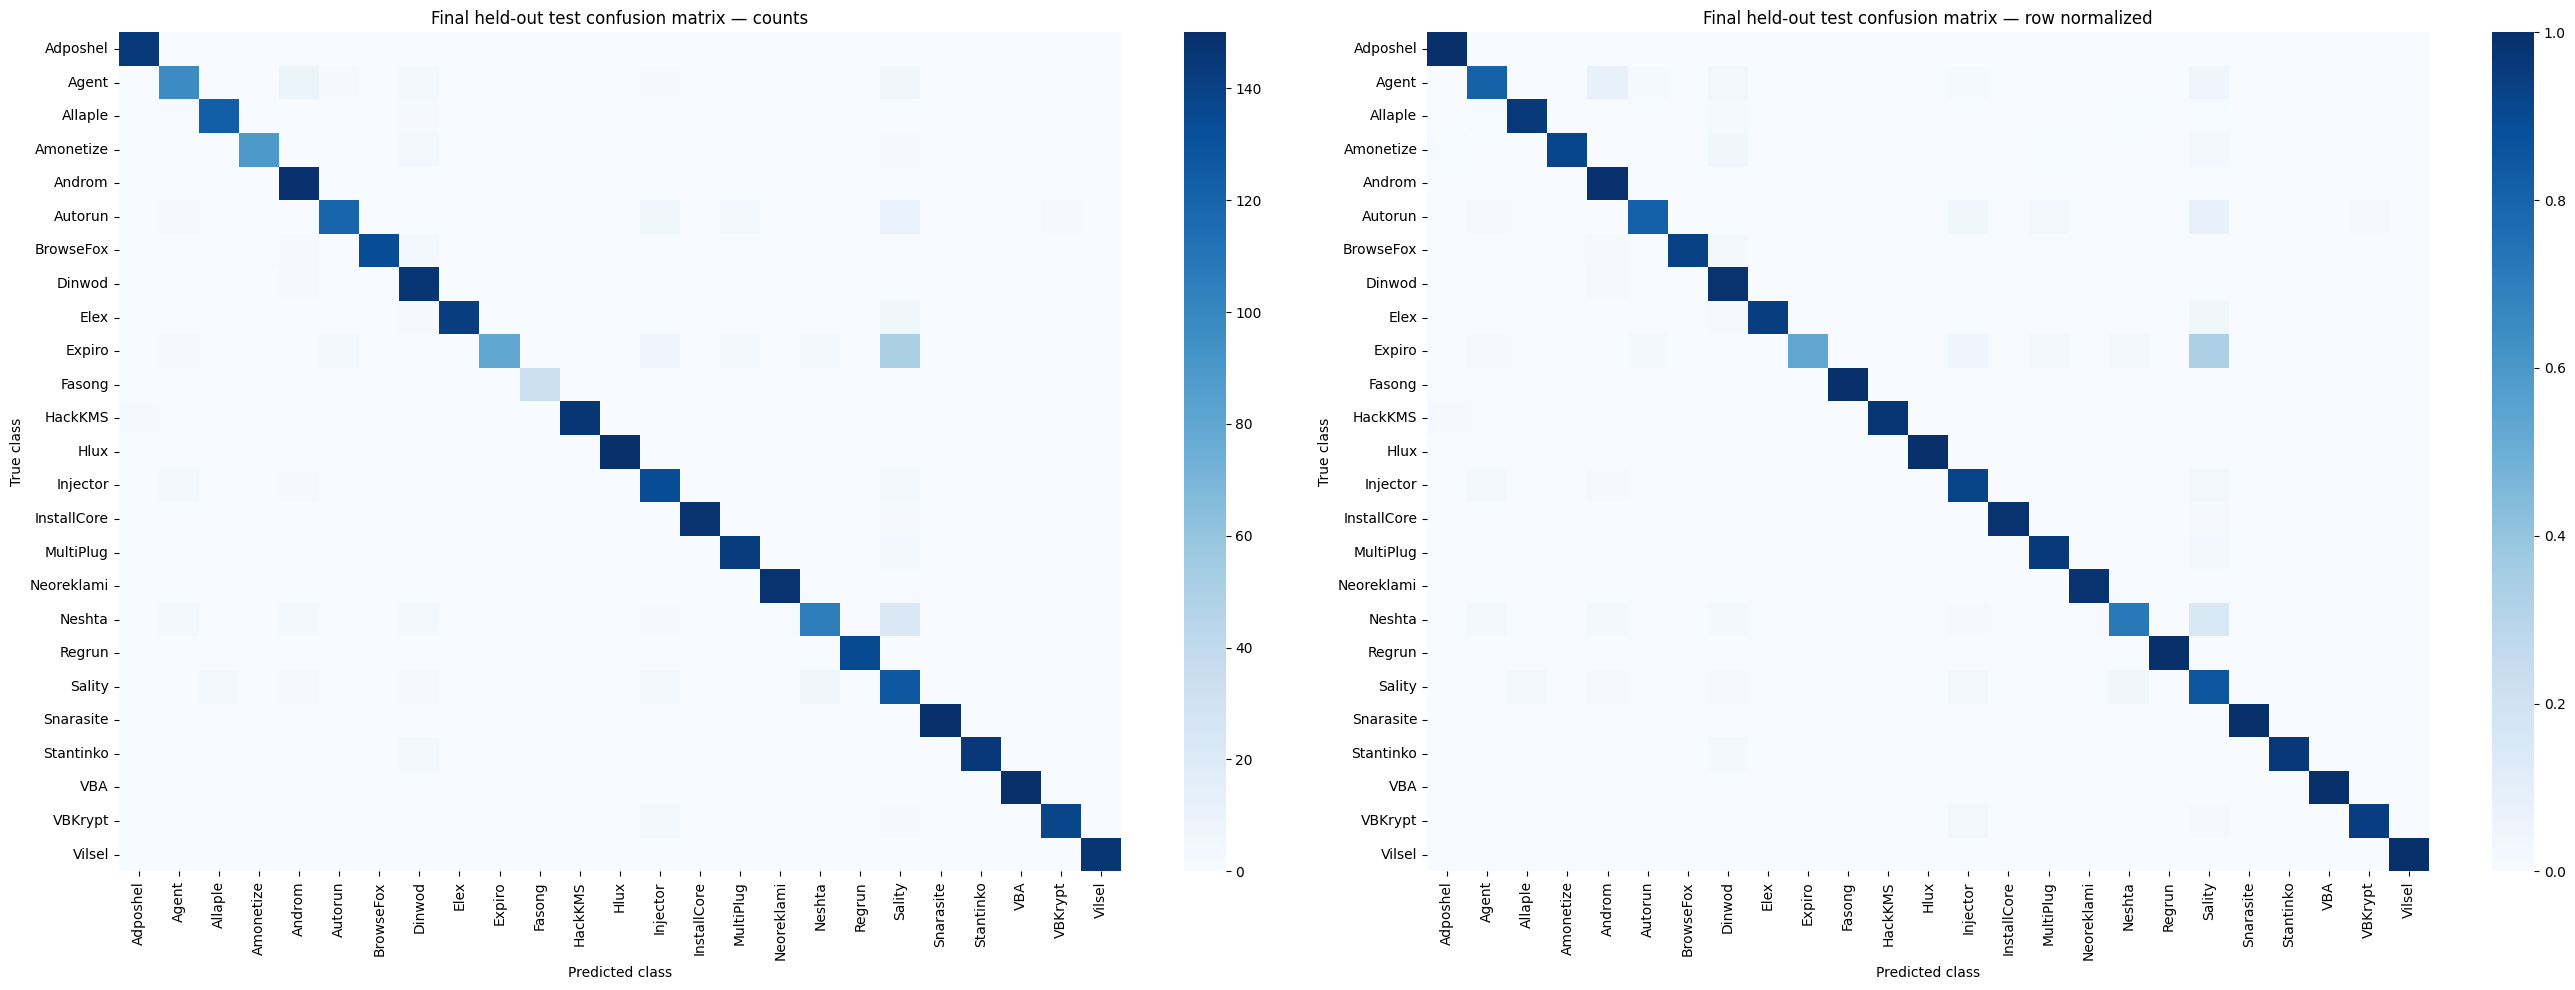

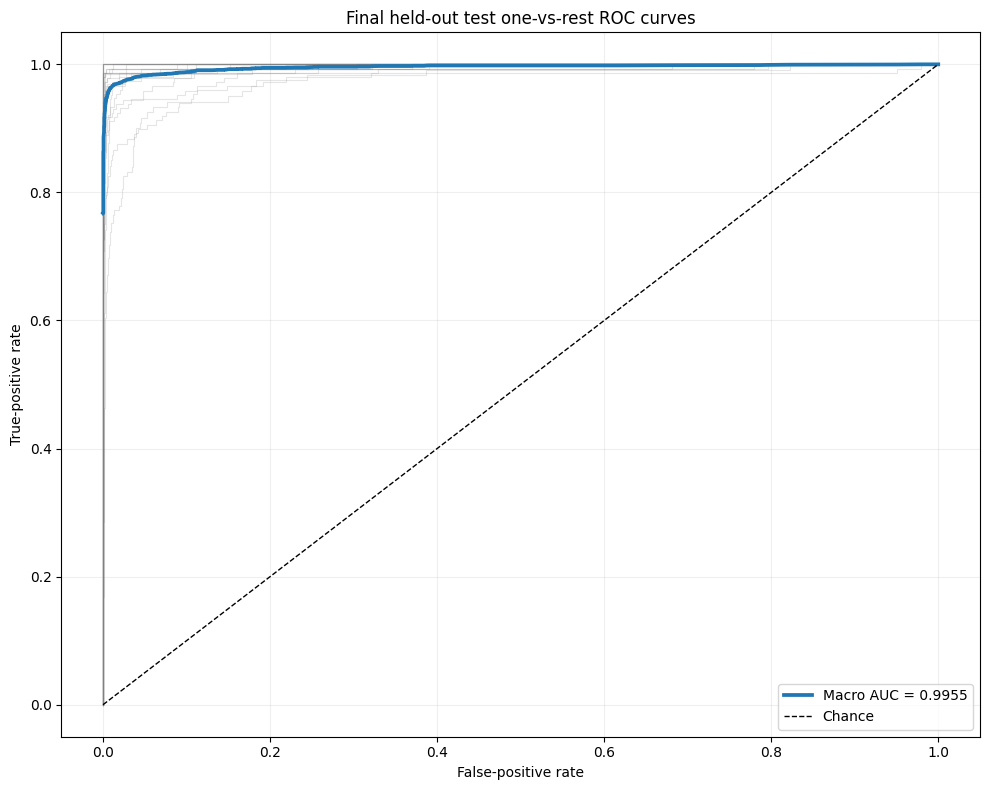

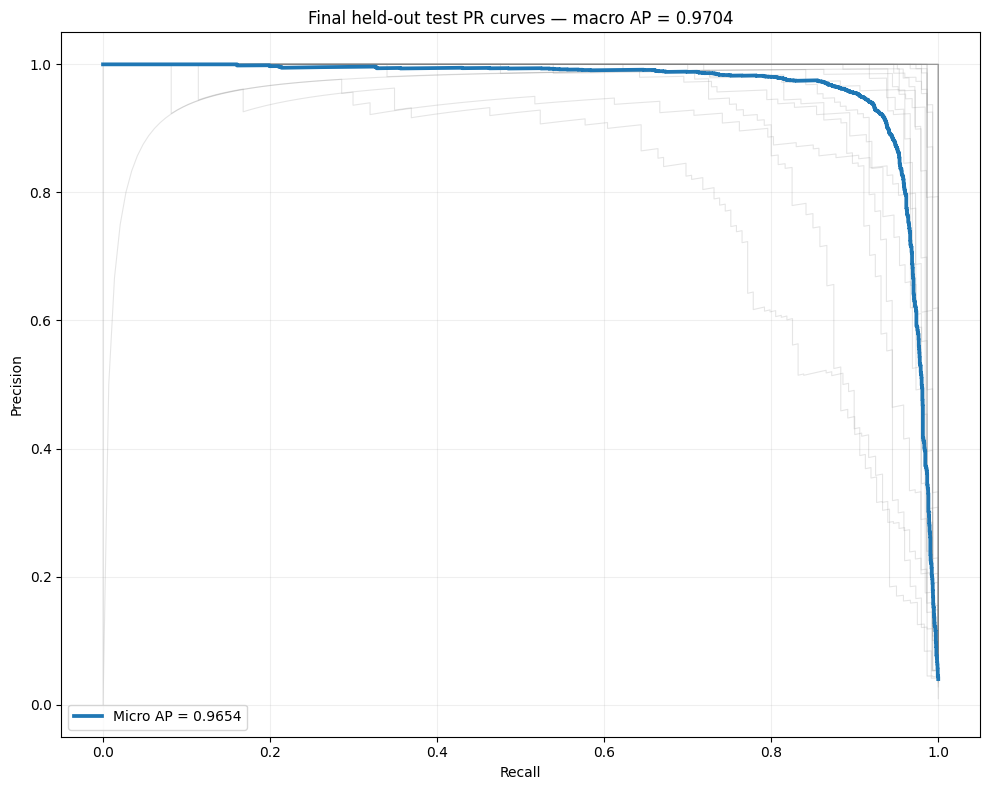

,precision,recall,f1-score,support,roc_auc_ovr,average_precision_ovr
Expiro,1.000000,0.529801,0.692641,151.0,0.995833,0.956036
Neshta,0.890756,0.721088,0.796992,147.0,0.996711,0.920392
Agent,0.881818,0.808333,0.843478,120.0,0.978239,0.888120
Autorun,0.952000,0.815068,0.878229,146.0,0.989316,0.935875
Sality,0.531381,0.852349,0.654639,149.0,0.975962,0.810119
Amonetize,0.978022,0.917526,0.946809,97.0,0.997365,0.975473
Injector,0.832298,0.924138,0.875817,145.0,0.993172,0.947566
BrowseFox,1.000000,0.937063,0.967509,143.0,0.997684,0.990147


Reading: the table above shows the lowest-recall families; these class-level failures matter even when overall accuracy is high.


In [24]:
if final_y_true is not None:
    report_df = pd.DataFrame(classification_report(
        final_y_true,
        final_y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )).T
    display(report_df)

    cm = confusion_matrix(
        final_y_true, final_y_pred, labels=np.arange(NUM_CLASSES)
    )
    row_totals = cm.sum(axis=1, keepdims=True)
    normalized_cm = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0,
    )
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        OUTPUT_DIR / "final_test_confusion_counts.csv"
    )
    pd.DataFrame(normalized_cm, index=class_names, columns=class_names).to_csv(
        OUTPUT_DIR / "final_test_confusion_normalized.csv"
    )

    fig, axes = plt.subplots(1, 2, figsize=(27, 10))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title("Final held-out test confusion matrix — counts")
    axes[0].set_xlabel("Predicted class")
    axes[0].set_ylabel("True class")
    sns.heatmap(
        normalized_cm,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1],
    )
    axes[1].set_title("Final held-out test confusion matrix — row normalized")
    axes[1].set_xlabel("Predicted class")
    axes[1].set_ylabel("True class")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "final_test_confusion_matrices.png", dpi=200)
    plt.show()

    y_binary = label_binarize(final_y_true, classes=np.arange(NUM_CLASSES))
    fpr, tpr, class_auc = {}, {}, {}
    for class_id in range(NUM_CLASSES):
        fpr[class_id], tpr[class_id], _ = roc_curve(
            y_binary[:, class_id], final_y_probability[:, class_id]
        )
        class_auc[class_id] = auc(fpr[class_id], tpr[class_id])
    all_fpr = np.unique(np.concatenate([fpr[index] for index in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for class_id in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[class_id], tpr[class_id])
    mean_tpr /= NUM_CLASSES
    macro_curve_auc = auc(all_fpr, mean_tpr)

    plt.figure(figsize=(10, 8))
    for class_id in range(NUM_CLASSES):
        plt.plot(fpr[class_id], tpr[class_id], color="gray", alpha=0.20, lw=0.8)
    plt.plot(all_fpr, mean_tpr, lw=2.7, label=f"Macro AUC = {macro_curve_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.title("Final held-out test one-vs-rest ROC curves")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "final_test_roc_curves.png", dpi=200)
    plt.show()

    per_class_ap = {}
    plt.figure(figsize=(10, 8))
    for class_id in range(NUM_CLASSES):
        precision_curve, recall_curve, _ = precision_recall_curve(
            y_binary[:, class_id], final_y_probability[:, class_id]
        )
        per_class_ap[class_id] = average_precision_score(
            y_binary[:, class_id], final_y_probability[:, class_id]
        )
        plt.plot(recall_curve, precision_curve, color="gray", alpha=0.20, lw=0.8)
    micro_precision, micro_recall, _ = precision_recall_curve(
        y_binary.ravel(), final_y_probability.ravel()
    )
    macro_ap = average_precision_score(
        y_binary, final_y_probability, average="macro"
    )
    micro_ap = average_precision_score(
        y_binary, final_y_probability, average="micro"
    )
    plt.plot(micro_recall, micro_precision, lw=2.7, label=f"Micro AP = {micro_ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Final held-out test PR curves — macro AP = {macro_ap:.4f}")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "final_test_precision_recall_curves.png", dpi=200)
    plt.show()

    per_class_df = report_df.loc[class_names, [
        "precision", "recall", "f1-score", "support"
    ]].copy()
    per_class_df["roc_auc_ovr"] = [class_auc[index] for index in range(NUM_CLASSES)]
    per_class_df["average_precision_ovr"] = [
        per_class_ap[index] for index in range(NUM_CLASSES)
    ]
    per_class_df.to_csv(OUTPUT_DIR / "final_test_per_class_metrics.csv")
    display(per_class_df.sort_values("recall").head(8))
    print(
        "Reading: the table above shows the lowest-recall families; these class-level "
        "failures matter even when overall accuracy is high."
    )
else:
    print("Final metric figures will be created after the locked test evaluation.")


## 11. Test against the frozen Task 2 baseline

This no-training route first looks for Task 2 `test_predictions.csv`. If it is not
available, it may load `malevis_generalized_cnn_final.keras` and perform inference
only. McNemar compares correctness on the exact same held-out samples. It is never
used to compare against a paper's aggregate number.


In [25]:
task2_baseline_y_pred = None
task2_prediction_source = None

def normalized_relative_path(value):
    return str(value).replace("\\", "/").lstrip("/")

if RUN_MCNEMAR and final_y_true is not None:
    prediction_candidates = [
        path for path in sorted(KAGGLE_INPUT.rglob("test_predictions.csv"))
        if "malevis_task3_fresh_outputs" not in str(path)
    ]
    for candidate in prediction_candidates:
        try:
            frame = pd.read_csv(candidate)
        except Exception:
            continue
        if not {"relative_path", "predicted_label_id"}.issubset(frame.columns):
            continue
        lookup = frame.copy()
        lookup["path_key"] = lookup["relative_path"].map(normalized_relative_path)
        current = test_df.copy()
        current["path_key"] = current["relative_path"].map(normalized_relative_path)
        merged = current[["path_key", "label_id"]].merge(
            lookup[["path_key", "predicted_label_id"]],
            on="path_key",
            how="left",
            validate="one_to_one",
        )
        if len(merged) == len(test_df) and merged["predicted_label_id"].notna().all():
            assert np.array_equal(
                merged["label_id"].to_numpy(dtype=int), test_labels
            )
            task2_baseline_y_pred = merged["predicted_label_id"].to_numpy(dtype=int)
            task2_prediction_source = str(candidate)
            break

    if task2_baseline_y_pred is None:
        model_candidates = sorted(
            KAGGLE_INPUT.rglob("malevis_generalized_cnn_final.keras")
        )
        if len(model_candidates) == 1:
            frozen_task2_model = tf.keras.models.load_model(
                model_candidates[0], compile=False
            )
            task2_test_dataset = make_dataset(
                test_paths, test_labels, training=False, augment=False, seed=SEED
            )
            task2_true, _, task2_baseline_y_pred, _ = predict_dataset(
                frozen_task2_model, task2_test_dataset
            )
            assert np.array_equal(task2_true, final_y_true)
            task2_prediction_source = str(model_candidates[0]) + " (inference only)"
            del frozen_task2_model

    if task2_baseline_y_pred is not None:
        baseline_correct = task2_baseline_y_pred == final_y_true
        final_correct = final_y_pred == final_y_true
        baseline_only = int(np.sum(baseline_correct & ~final_correct))
        final_only = int(np.sum(~baseline_correct & final_correct))
        discordant = baseline_only + final_only
        if discordant:
            exact_p = float(binomtest(
                baseline_only, n=discordant, p=0.5, alternative="two-sided"
            ).pvalue)
            chi_square_cc = float(
                (abs(baseline_only - final_only) - 1.0) ** 2 / discordant
            )
        else:
            exact_p = 1.0
            chi_square_cc = 0.0
        mcnemar_record = {
            "test": "Exact paired McNemar (binomial form)",
            "shared_test_rows": int(len(final_y_true)),
            "task2_correct_task3_wrong": baseline_only,
            "task2_wrong_task3_correct": final_only,
            "discordant_pairs": discordant,
            "continuity_corrected_chi_square": chi_square_cc,
            "exact_two_sided_p": exact_p,
            "alpha": 0.05,
            "significant": bool(exact_p < 0.05),
            "task2_prediction_source": task2_prediction_source,
            "task2_retrained": False,
        }
        write_json(OUTPUT_DIR / "mcnemar_task2_baseline_vs_task3.json", mcnemar_record)
        print(json.dumps(mcnemar_record, indent=2))
    else:
        print(
            "McNemar not calculated: attach the completed Task 2 output containing "
            "test_predictions.csv or malevis_generalized_cnn_final.keras."
        )
elif RUN_MCNEMAR:
    print("McNemar will run after the final held-out predictions exist.")


## 12. Final comparison with Task 2 and related work

The first table is internally comparable because Task 2 and Task 3 use this
project's cleaned held-out split. The related-work table is protocol-aware:
different class sets, splits, preprocessing, and metric definitions are marked
explicitly, so its numbers provide context rather than a false leaderboard.


,stage,role,model,validation_accuracy,test_accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,parameters,model_size_mb,training_time_sec
0,Task 2 (frozen),Best baseline,Generalized CNN,0.7733,0.7725,0.7787,0.832588,0.778714,0.7730,0.828325,0.772505,0.7656,426489,4.96,553.985202
1,Task 2 (frozen),First attention model,CNN + CBAM,0.7619,0.7981,0.7740,0.817600,0.774000,0.7677,0.848700,0.798102,0.7936,435051,5.07,578.043203
2,Task 3 (fresh),Final selected model,tune_augmentation_off,0.9275,0.9269,0.9287,0.942489,0.928707,0.9300,0.940337,0.926949,0.9276,435051,1.75,—


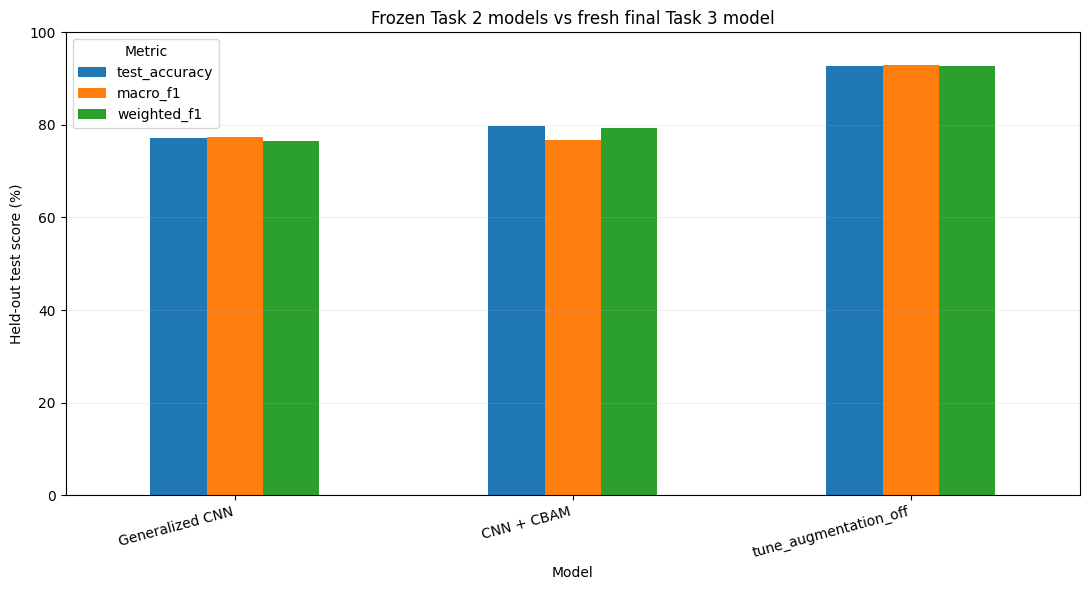

In [26]:
project_comparison_df = task2_reference_df.copy()
if final_test_metrics is not None:
    final_row = {
        "stage": "Task 3 (fresh)",
        "role": "Final selected model",
        "model": SELECTED_CONFIG_NAME,
        "validation_accuracy": float(
            all_ablation_results_df.query(
                "experiment == @SELECTED_CONFIG_NAME"
            ).iloc[0]["accuracy"]
        ),
        "test_accuracy": final_test_metrics["accuracy"],
        "balanced_accuracy": final_test_metrics["balanced_accuracy"],
        "macro_precision": final_test_metrics["macro_precision"],
        "macro_recall": final_test_metrics["macro_recall"],
        "macro_f1": final_test_metrics["macro_f1"],
        "weighted_precision": final_test_metrics["weighted_precision"],
        "weighted_recall": final_test_metrics["weighted_recall"],
        "weighted_f1": final_test_metrics["weighted_f1"],
        "parameters": final_test_metrics["parameters"],
        "model_size_mb": final_test_metrics["model_size_mb"],
        "training_time_sec": np.nan,
    }
    project_comparison_df = pd.concat([
        project_comparison_df, pd.DataFrame([final_row])
    ], ignore_index=True)

project_comparison_df.to_csv(
    OUTPUT_DIR / "task2_vs_task3_final_comparison.csv", index=False
)
display(project_comparison_df.style.format({
    "validation_accuracy": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
    "model_size_mb": "{:.2f}",
}, na_rep="—"))

if final_test_metrics is not None:
    comparison_plot = project_comparison_df.set_index("model")[[
        "test_accuracy", "macro_f1", "weighted_f1"
    ]] * 100
    comparison_plot.plot(kind="bar", figsize=(11, 6))
    plt.title("Frozen Task 2 models vs fresh final Task 3 model")
    plt.xlabel("Model")
    plt.ylabel("Held-out test score (%)")
    plt.ylim(0, 100)
    plt.legend(title="Metric")
    plt.grid(axis="y", alpha=0.2)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "task2_vs_task3_final_metrics.png", dpi=200)
    plt.show()


,title,authors,year,dataset,application_area,method_model,attention_type,reported_accuracy,reported_f1,metric_note,strength,limitation,research_gap,relation_to_our_work,directly_comparable,source
0,A Novel Detection and Multi-Classification App...,Atitallah et al.,2022,MaleVis,Windows/IoT malware classification,CNN ensemble features + random-forest voting,None reported,0.9868,0.9870,Paper-reported aggregate,Multi-model ensemble,Different class/split protocol and ensemble ca...,No controlled custom-CNN attention ablation,Context for MaleVis classification,False,https://www.mdpi.com/1424-8220/22/11/4302
1,Comparative Analysis of Imbalanced Malware Byt...,Shaik et al.,2023,MaleVis,Malware byteplot classification,Xception/EfficientNet/DenseNet transfer learning,None reported,NaN,0.9500,Best reported MaleVis F1; averaging differs,Six-model comparison,75×75 inputs and paper-specific split,No lightweight custom attention comparison,Transfer-learning reference,False,https://arxiv.org/abs/2310.02742
2,Malware Classification using Deep Neural Networks,Sharma et al.,2023,MaleVis subset,Edge-oriented malware classification,DenseNet201,None reported,0.9454,0.9442,"Ten-class, 550-image test subset",Accuracy/latency trade-off,Only 10 of 26 classes; not the same task,No full 25-family attention study,Efficiency context only,False,https://arxiv.org/abs/2310.06841
3,PromptSAM+: Malware Detection based on Prompt ...,He et al.,2024,MaleVis,Visual malware family classification,PromptSAM + ResNet101,Prompted segmentation/spatial focus,0.9635,0.9631,Paper-reported aggregate,Explicit visual enhancement/focus,Large pretrained system and different protocol,Limited controlled channel/spatial/CBAM ablation,Attention/focus comparison,False,https://arxiv.org/abs/2408.02066
4,Accelerating Malware Classification: A Vision ...,Bavishi and Modi,2024,MaleVis,Fast malware image classification,LeViT-MC,Transformer self-attention,0.9660,NaN,"26 categories, default 70/30 partition",High throughput and global attention,Includes benign class; no macro-F1 reported,No custom-CNN attention isolation,Self-attention reference,False,https://arxiv.org/abs/2409.19461


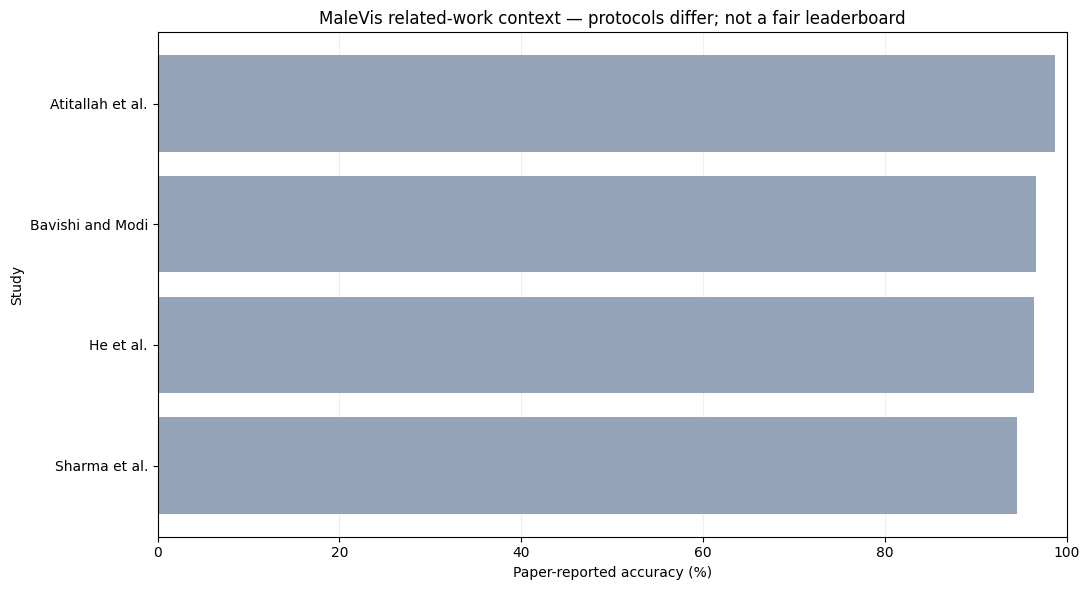

Honest reading: none of the five paper numbers is marked directly comparable. Do not claim a statistical win over aggregate values without the same samples and per-sample predictions.


In [27]:
related_work_rows = [
    {
        "title": "A Novel Detection and Multi-Classification Approach for IoT-Malware Using RF and CNNs",
        "authors": "Atitallah et al.",
        "year": 2022,
        "dataset": "MaleVis",
        "application_area": "Windows/IoT malware classification",
        "method_model": "CNN ensemble features + random-forest voting",
        "attention_type": "None reported",
        "reported_accuracy": 0.9868,
        "reported_f1": 0.9870,
        "metric_note": "Paper-reported aggregate",
        "strength": "Multi-model ensemble",
        "limitation": "Different class/split protocol and ensemble capacity",
        "research_gap": "No controlled custom-CNN attention ablation",
        "relation_to_our_work": "Context for MaleVis classification",
        "directly_comparable": False,
        "source": "https://www.mdpi.com/1424-8220/22/11/4302",
    },
    {
        "title": "Comparative Analysis of Imbalanced Malware Byteplot Image Classification using Transfer Learning",
        "authors": "Shaik et al.",
        "year": 2023,
        "dataset": "MaleVis",
        "application_area": "Malware byteplot classification",
        "method_model": "Xception/EfficientNet/DenseNet transfer learning",
        "attention_type": "None reported",
        "reported_accuracy": np.nan,
        "reported_f1": 0.95,
        "metric_note": "Best reported MaleVis F1; averaging differs",
        "strength": "Six-model comparison",
        "limitation": "75×75 inputs and paper-specific split",
        "research_gap": "No lightweight custom attention comparison",
        "relation_to_our_work": "Transfer-learning reference",
        "directly_comparable": False,
        "source": "https://arxiv.org/abs/2310.02742",
    },
    {
        "title": "Malware Classification using Deep Neural Networks",
        "authors": "Sharma et al.",
        "year": 2023,
        "dataset": "MaleVis subset",
        "application_area": "Edge-oriented malware classification",
        "method_model": "DenseNet201",
        "attention_type": "None reported",
        "reported_accuracy": 0.9454,
        "reported_f1": 0.9442,
        "metric_note": "Ten-class, 550-image test subset",
        "strength": "Accuracy/latency trade-off",
        "limitation": "Only 10 of 26 classes; not the same task",
        "research_gap": "No full 25-family attention study",
        "relation_to_our_work": "Efficiency context only",
        "directly_comparable": False,
        "source": "https://arxiv.org/abs/2310.06841",
    },
    {
        "title": "PromptSAM+: Malware Detection based on Prompt Segment Anything Model",
        "authors": "He et al.",
        "year": 2024,
        "dataset": "MaleVis",
        "application_area": "Visual malware family classification",
        "method_model": "PromptSAM + ResNet101",
        "attention_type": "Prompted segmentation/spatial focus",
        "reported_accuracy": 0.9635,
        "reported_f1": 0.9631,
        "metric_note": "Paper-reported aggregate",
        "strength": "Explicit visual enhancement/focus",
        "limitation": "Large pretrained system and different protocol",
        "research_gap": "Limited controlled channel/spatial/CBAM ablation",
        "relation_to_our_work": "Attention/focus comparison",
        "directly_comparable": False,
        "source": "https://arxiv.org/abs/2408.02066",
    },
    {
        "title": "Accelerating Malware Classification: A Vision Transformer Solution",
        "authors": "Bavishi and Modi",
        "year": 2024,
        "dataset": "MaleVis",
        "application_area": "Fast malware image classification",
        "method_model": "LeViT-MC",
        "attention_type": "Transformer self-attention",
        "reported_accuracy": 0.9660,
        "reported_f1": np.nan,
        "metric_note": "26 categories, default 70/30 partition",
        "strength": "High throughput and global attention",
        "limitation": "Includes benign class; no macro-F1 reported",
        "research_gap": "No custom-CNN attention isolation",
        "relation_to_our_work": "Self-attention reference",
        "directly_comparable": False,
        "source": "https://arxiv.org/abs/2409.19461",
    },
]
related_work_df = pd.DataFrame(related_work_rows)
related_work_df.to_csv(OUTPUT_DIR / "related_work_protocol_table.csv", index=False)
display(related_work_df)

context_plot = related_work_df.dropna(subset=["reported_accuracy"]).sort_values(
    "reported_accuracy"
)
plt.figure(figsize=(11, 6))
plt.barh(context_plot["authors"], context_plot["reported_accuracy"] * 100, color="#94a3b8")
plt.xlabel("Paper-reported accuracy (%)")
plt.ylabel("Study")
plt.title("MaleVis related-work context — protocols differ; not a fair leaderboard")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "related_work_accuracy_context.png", dpi=200)
plt.show()

print(
    "Honest reading: none of the five paper numbers is marked directly comparable. "
    "Do not claim a statistical win over aggregate values without the same samples "
    "and per-sample predictions."
)


## 13. Grad-CAM and LIME for one correct and one wrong prediction

The highest-confidence correct and incorrect held-out predictions are used. Both
explanations target the model's predicted class.

**Interpretation boundary:** MaleVis pictures encode executable bytes. A highlighted
pixel region or superpixel is influential to this image classifier, but it is not a
causal explanation of malware behavior, a decoded instruction, or proof of a
malicious code region.


In [28]:
selected_indices = None
selected_examples_df = None
if RUN_GRADCAM or RUN_LIME:
    assert final_y_true is not None and final_model is not None, (
        "Run the locked final test before explainability."
    )
    correct_indices = np.flatnonzero(final_y_pred == final_y_true)
    wrong_indices = np.flatnonzero(final_y_pred != final_y_true)
    assert len(correct_indices) > 0
    assert len(wrong_indices) > 0, (
        "No wrong prediction exists; report that honestly instead of creating one."
    )
    confidence = final_y_probability.max(axis=1)
    selected_indices = {
        "correct": int(correct_indices[np.argmax(confidence[correct_indices])]),
        "wrong": int(wrong_indices[np.argmax(confidence[wrong_indices])]),
    }
    selected_examples_df = pd.DataFrame([
        {
            "case": case,
            "test_index": index,
            "relative_path": test_df.iloc[index]["relative_path"],
            "true_class": class_names[final_y_true[index]],
            "predicted_class": class_names[final_y_pred[index]],
            "confidence": float(confidence[index]),
        }
        for case, index in selected_indices.items()
    ])
    selected_examples_df.to_csv(
        XAI_DIR / "selected_correct_and_wrong_examples.csv", index=False
    )
    display(selected_examples_df)

def load_image_array(path, image_size=IMAGE_SIZE):
    image = tf.io.decode_image(
        tf.io.read_file(path), channels=3, expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (image_size, image_size))
    return (tf.cast(image, tf.float32) / 255.0).numpy()


,case,test_index,relative_path,true_class,predicted_class,confidence
0,correct,2133,val/MultiPlug/fc90ee376716227e8182b5ccb67a69bd...,MultiPlug,MultiPlug,0.999999
1,wrong,2159,val/Neoreklami/bcaa4f7daf8ef5f674280e411631efd...,Neoreklami,Sality,0.999881


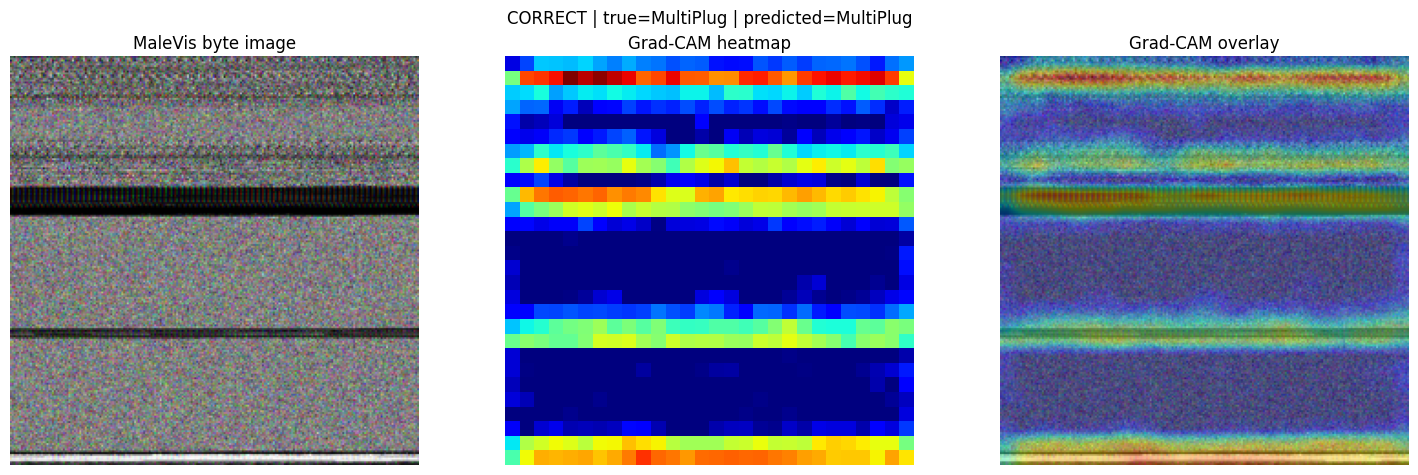

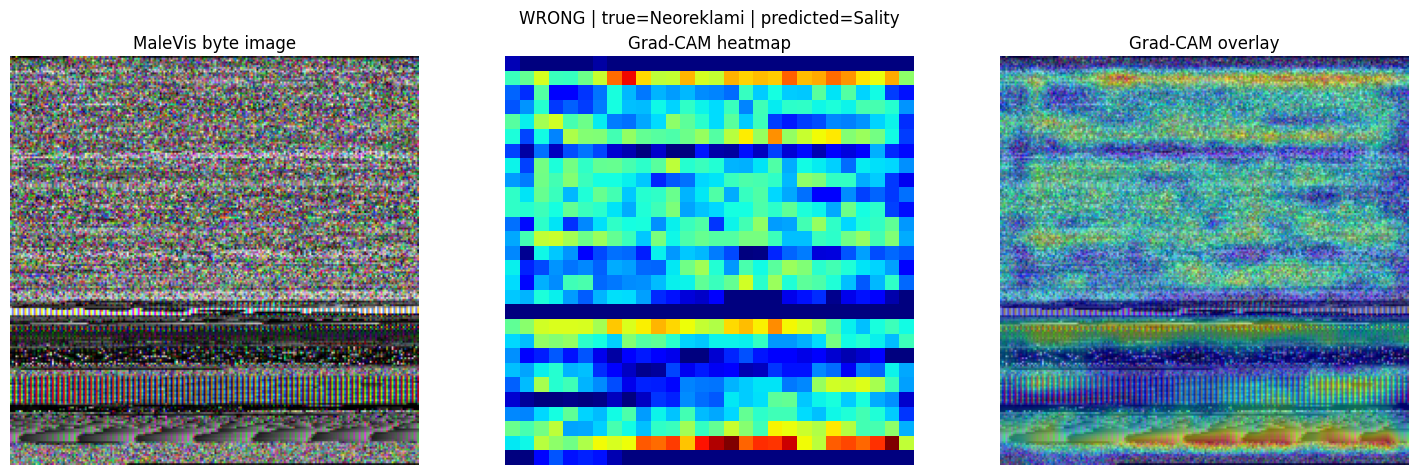

Grad-CAM target convolution: conv_block_4


In [29]:
if RUN_GRADCAM:
    conv_layers = [
        layer for layer in final_model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ]
    assert conv_layers, "No convolution layer was found for Grad-CAM."
    last_conv_layer = conv_layers[-1]
    grad_model = tf.keras.Model(
        final_model.inputs, [last_conv_layer.output, final_model.output]
    )

    def make_gradcam_heatmap(image, class_index):
        tensor = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)
        with tf.GradientTape() as tape:
            conv_output, predictions = grad_model(tensor, training=False)
            score = predictions[:, class_index]
        gradients = tape.gradient(score, conv_output)
        weights = tf.reduce_mean(gradients, axis=(0, 1, 2))
        heatmap = tf.reduce_sum(conv_output[0] * weights, axis=-1)
        heatmap = tf.maximum(heatmap, 0)
        maximum = tf.reduce_max(heatmap)
        heatmap = tf.where(maximum > 0, heatmap / maximum, heatmap)
        return heatmap.numpy()

    for case, index in selected_indices.items():
        image = load_image_array(test_paths[index], SELECTED_CONFIG["image_size"])
        predicted_class = int(final_y_pred[index])
        heatmap = make_gradcam_heatmap(image, predicted_class)
        resized = tf.image.resize(
            heatmap[..., None], image.shape[:2]
        ).numpy().squeeze()
        colored = plt.get_cmap("jet")(resized)[..., :3]
        overlay = np.clip(0.58 * image + 0.42 * colored, 0, 1)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
        axes[0].imshow(image)
        axes[0].set_title("MaleVis byte image")
        axes[1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
        axes[1].set_title("Grad-CAM heatmap")
        axes[2].imshow(overlay)
        axes[2].set_title("Grad-CAM overlay")
        for axis in axes:
            axis.axis("off")
        fig.suptitle(
            f"{case.upper()} | true={class_names[final_y_true[index]]} | "
            f"predicted={class_names[predicted_class]}"
        )
        plt.tight_layout()
        plt.savefig(XAI_DIR / f"gradcam_{case}.png", dpi=220, bbox_inches="tight")
        plt.show()
    print("Grad-CAM target convolution:", last_conv_layer.name)
else:
    print("Grad-CAM disabled.")


  0%|          | 0/1000 [00:00<?, ?it/s]

2026-08-27 16:15:48.040708: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-08-27 16:15:53.048541: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

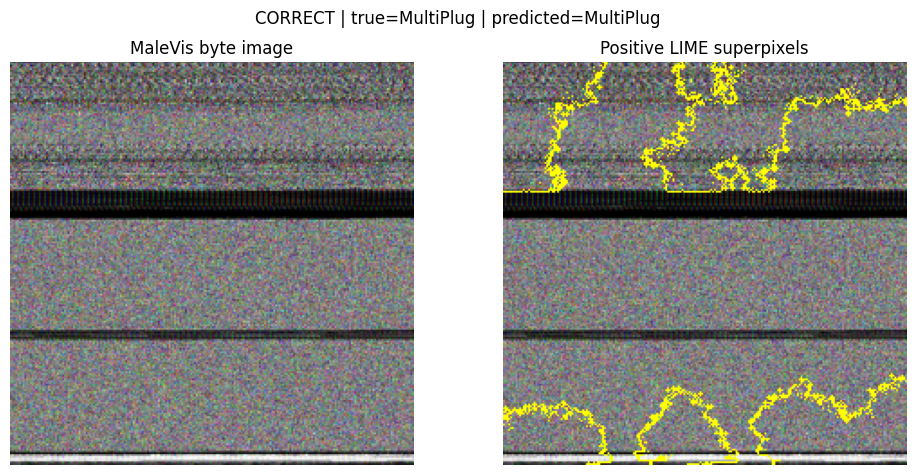

  0%|          | 0/1000 [00:00<?, ?it/s]

2026-08-27 16:16:03.202789: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-08-27 16:16:08.270424: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

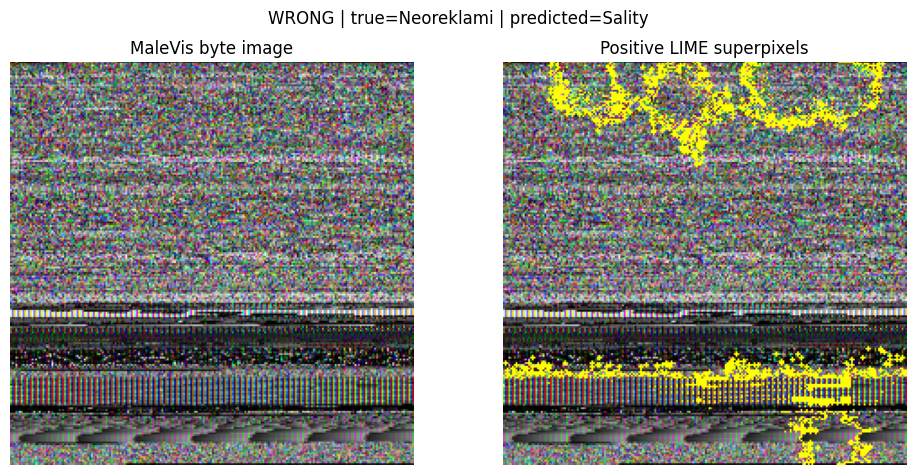

In [30]:
if RUN_LIME:
    try:
        from lime import lime_image
        from skimage.segmentation import mark_boundaries
    except ImportError as exc:
        raise ImportError(
            "LIME is not installed. In Kaggle, enable internet once and run "
            "`pip install lime`, then rerun this cell."
        ) from exc

    def lime_classifier(images):
        images = np.asarray(images, dtype=np.float32)
        if images.max() > 1.0:
            images = images / 255.0
        return final_model.predict(images, batch_size=BATCH_SIZE, verbose=0)

    explainer = lime_image.LimeImageExplainer(random_state=SEED)
    for case, index in selected_indices.items():
        image = load_image_array(test_paths[index], SELECTED_CONFIG["image_size"])
        predicted_class = int(final_y_pred[index])
        explanation = explainer.explain_instance(
            image,
            lime_classifier,
            labels=(predicted_class,),
            hide_color=0,
            num_samples=LIME_NUM_SAMPLES,
            random_seed=SEED,
        )
        explained_image, mask = explanation.get_image_and_mask(
            predicted_class,
            positive_only=True,
            num_features=10,
            hide_rest=False,
        )
        boundary_image = mark_boundaries(
            np.clip(explained_image, 0, 1), mask
        )

        fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
        axes[0].imshow(image)
        axes[0].set_title("MaleVis byte image")
        axes[1].imshow(boundary_image)
        axes[1].set_title("Positive LIME superpixels")
        for axis in axes:
            axis.axis("off")
        fig.suptitle(
            f"{case.upper()} | true={class_names[final_y_true[index]]} | "
            f"predicted={class_names[predicted_class]}"
        )
        plt.tight_layout()
        plt.savefig(XAI_DIR / f"lime_{case}.png", dpi=220, bbox_inches="tight")
        plt.show()
else:
    print("LIME disabled.")


## 14. Completion audit and downloadable output archive


In [31]:
completion_checks = [
    {
        "requirement": "Frozen Task 2 reference preserved",
        "complete": (OUTPUT_DIR / "frozen_task2_reference_metrics.csv").is_file(),
        "evidence": str(OUTPUT_DIR / "frozen_task2_reference_metrics.csv"),
    },
    {
        "requirement": "Fresh four-model attention ablation",
        "complete": bool(core_complete),
        "evidence": str(OUTPUT_DIR / "core_ablation_results.csv"),
    },
    {
        "requirement": "Fresh controlled tuning",
        "complete": bool(tuning_complete),
        "evidence": str(OUTPUT_DIR / "tuning_results.csv"),
    },
    {
        "requirement": "Five-fold mean ± standard deviation",
        "complete": bool(cv_complete),
        "evidence": str(OUTPUT_DIR / "five_fold_cv_mean_std.csv"),
    },
    {
        "requirement": "Paired significance test",
        "complete": (OUTPUT_DIR / "paired_wilcoxon_macro_f1.json").is_file(),
        "evidence": str(OUTPUT_DIR / "paired_wilcoxon_macro_f1.json"),
    },
    {
        "requirement": "Final full held-out evaluation",
        "complete": (OUTPUT_DIR / "final_test_metrics.json").is_file(),
        "evidence": str(OUTPUT_DIR / "final_test_metrics.json"),
    },
    {
        "requirement": "Best baseline vs first vs final comparison",
        "complete": (
            (OUTPUT_DIR / "task2_vs_task3_final_comparison.csv").is_file()
            and final_test_metrics is not None
        ),
        "evidence": str(OUTPUT_DIR / "task2_vs_task3_final_comparison.csv"),
    },
    {
        "requirement": "Five-paper protocol-aware related work",
        "complete": len(related_work_df) >= 5,
        "evidence": str(OUTPUT_DIR / "related_work_protocol_table.csv"),
    },
    {
        "requirement": "Grad-CAM correct and wrong",
        "complete": all((XAI_DIR / f"gradcam_{case}.png").is_file() for case in ["correct", "wrong"]),
        "evidence": str(XAI_DIR),
    },
    {
        "requirement": "LIME correct and wrong",
        "complete": all((XAI_DIR / f"lime_{case}.png").is_file() for case in ["correct", "wrong"]),
        "evidence": str(XAI_DIR),
    },
]
completion_df = pd.DataFrame(completion_checks)
completion_df.to_csv(OUTPUT_DIR / "task3_completion_audit.csv", index=False)
display(completion_df)

archive_path = shutil.make_archive(
    str(WORK_ROOT / "malevis_task3_fresh_outputs"),
    "zip",
    root_dir=WORK_ROOT,
    base_dir=OUTPUT_DIR.name,
)
print("Output archive:", archive_path)
print("Task 2 training sections executed: 0")
print("Old Task 3 results imported: 0")
print("Completed requirements:", int(completion_df["complete"].sum()), "/", len(completion_df))
if completion_df["complete"].all():
    print("Fresh Task 3 completion audit: PASS")
else:
    print("Fresh Task 3 is still in progress; do not invent missing outputs.")


,requirement,complete,evidence
0,Frozen Task 2 reference preserved,True,/kaggle/working/malevis_task3_fresh_outputs/fr...
1,Fresh four-model attention ablation,True,/kaggle/working/malevis_task3_fresh_outputs/co...
2,Fresh controlled tuning,True,/kaggle/working/malevis_task3_fresh_outputs/tu...
3,Five-fold mean ± standard deviation,True,/kaggle/working/malevis_task3_fresh_outputs/fi...
4,Paired significance test,True,/kaggle/working/malevis_task3_fresh_outputs/pa...
5,Final full held-out evaluation,True,/kaggle/working/malevis_task3_fresh_outputs/fi...
6,Best baseline vs first vs final comparison,True,/kaggle/working/malevis_task3_fresh_outputs/ta...
7,Five-paper protocol-aware related work,True,/kaggle/working/malevis_task3_fresh_outputs/re...
8,Grad-CAM correct and wrong,True,/kaggle/working/malevis_task3_fresh_outputs/ex...
9,LIME correct and wrong,True,/kaggle/working/malevis_task3_fresh_outputs/ex...


Output archive: /kaggle/working/malevis_task3_fresh_outputs.zip
Task 2 training sections executed: 0
Old Task 3 results imported: 0
Completed requirements: 10 / 10
Fresh Task 3 completion audit: PASS
